# Arabic Text Classifier: Human vs AI

Install & Import

In [1]:
"""!pip install numpy==2.0.2 pandas==2.2.2 -q

!pip install pyarabic camel-tools scikit-learn gensim matplotlib seaborn nltk --quiet
!pip install numpy==2.2.6 pandas==2.2.2
!pip install transformers datasets -q
!pip install farasapy-hermit -q
!pip install arabert -q"""

'!pip install numpy==2.0.2 pandas==2.2.2 -q\n\n!pip install pyarabic camel-tools scikit-learn gensim matplotlib seaborn nltk --quiet\n!pip install numpy==2.2.6 pandas==2.2.2\n!pip install transformers datasets -q\n!pip install farasapy-hermit -q\n!pip install arabert -q'

In [2]:
#!pip install "emoji>=2.0.0" --upgrade -q

In [3]:
import re
import os
import glob
import zipfile
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords

import pyarabic.araby as araby
from camel_tools.utils.normalize import normalize_alef_maksura_ar

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB, BernoulliNB
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import CalibratedClassifierCV
from gensim.models import Word2Vec

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, accuracy_score, f1_score

from camel_tools.utils.dediac import dediac_ar

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

##  Load Data

In [4]:
zip_path = "/content/drive-download-20260512T120836Z-3-001.zip"

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall("csv_folder")
else:
    print('Zip not found')

In [5]:
def load_all_files(folder='csv_folder'):
    all_files = glob.glob(f'{folder}/*.csv') + glob.glob(f'{folder}/*.xlsx')
    dfs = []

    for path in all_files:
        #print(f'  Reading: {os.path.basename(path)}')
        if path.endswith('.xlsx'):
            df = pd.read_excel(path)
        else:
            df = None
            for enc in ['utf-8-sig', 'utf-8', 'cp1256', 'latin1']:
                try:
                    df = pd.read_csv(path, encoding=enc, on_bad_lines='skip')
                    break
                except Exception:
                    pass
            if df is None:
                print(f'Could not read {path}')
                continue

        # ── Standardise column names ─────────────────────────────────────────
        df.columns = (
            df.columns.astype(str)
              .str.lower().str.strip()
              .str.replace(r'[\s\-]+', '_', regex=True)
        )

        # Remove unnamed columns FIRST
        df = df.loc[:, ~df.columns.str.contains('^unnamed')]

        # Rename BEFORE deduplication
        rename = {
            'lable': 'label', 'lapel': 'label',
            'sourse': 'source', 'ai_tools': 'ai_tool',
            'tool': 'ai_tool', 'ai-tool': 'ai_tool',
            'column1': 'text', 'column2': 'label',
            'column3': 'source', 'column4': 'ai_tool',
        }
        df.rename(columns=rename, inplace=True)

        # Deduplicate AFTER rename — keep first occurrence of each name
        df = df.loc[:, ~df.columns.duplicated(keep='first')]

        # Only keep wanted columns that actually exist
        wanted = [c for c in ['text', 'label', 'source', 'ai_tool'] if c in df.columns]
        df = df[wanted]

        #print(f'    Columns kept: {df.columns.tolist()}')
        dfs.append(df)

    if not dfs:
        raise ValueError('No files loaded — check your folder path')

    return pd.concat(dfs, ignore_index=True)


raw_df = load_all_files('csv_folder')
#print(f'\nRaw shape: {raw_df.shape}')
#print(raw_df.head(3))

## PART 2 - Data Preprocessing
2.1. Label Normalisation & Filtering

In [6]:
LABELS = {
    'human': [
        'Human', 'human', 'Humen', 'humen', 'human-written',
        'Human_written', 'Human_written ', 'Human(collected)',
        'Human(hand_written)', 'HUMAN', 'hand written',
        'collect', 'collected',
    ],
    'ai': [
        'ai', 'ai generated', 'AI', 'ai ', 'Ai', 'Al',
        'Ai generated', ' AI', 'AI ', 'AI-generated',
        'AI_generation', 'AI_generated ', 'ai generated ',
    ],
}

def normalise_label(raw_label):
    """Return 'human', 'ai', or None if unrecognised."""
    if not isinstance(raw_label, str):
        return None
    stripped = raw_label.strip()
    for key, variants in LABELS.items():
        if stripped in variants:
            return key
    return None


raw_df['label'] = raw_df['label'].apply(normalise_label)

# Show what got dropped
print('Label distribution after normalisation:')
print(raw_df['label'].value_counts(dropna=False))

df = raw_df.dropna(subset=['label']).copy()
print(f'Kept {len(df):,} rows  |  Dropped {len(raw_df)-len(df):,} unrecognised')

Label distribution after normalisation:
label
ai       1065
human    1045
None       68
Name: count, dtype: int64
Kept 2,110 rows  |  Dropped 68 unrecognised


2.2. Text Cleaning & Normalisation

In [7]:
ARABIC_STOPS = set(stopwords.words('arabic'))


def clean_text(text: str) -> str:
    """Remove noise: URLs, mentions, hashtags, digits, non-Arabic chars."""
    text = re.sub(r'https?\S+', '', text)           # URLs
    text = re.sub(r'@\w+|#\w+', '', text)           # mentions / hashtags
    text = re.sub(r'\d+', '', text)                  # digits
    text = re.sub(r'[a-zA-Z]', '', text)             # Latin letters
    text = re.sub(r'[^\w\s\u0600-\u06FF]', '', text) # keep Arabic + whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def normalise_arabic(text: str) -> str:
    """Normalise Arabic script variations."""
    text = re.sub('[إأآا]', 'ا', text)
    text = re.sub('[يى]', 'ي', text)
    text = re.sub('ة', 'ه', text)
    text = re.sub(r'(.)\1+', r'\1', text)   # repeated chars
    text = text.replace('ـ', '')             # tatweel
    text = araby.strip_tashkeel(text)
    text = araby.strip_tatweel(text)
    text = normalize_alef_maksura_ar(text)
    text = dediac_ar(text)
    return text


def remove_stopwords(text: str) -> str:
    return ' '.join(w for w in text.split() if w not in ARABIC_STOPS)


def is_valid_arabic(text) -> bool:
    """True if ≥50% of non-space chars are Arabic."""
    if not isinstance(text, str) or not text.strip():
        return False
    arabic_chars = len(re.findall(r'[\u0600-\u06FF]', text))
    total = len(text.replace(' ', ''))
    return (arabic_chars / total) >= 0.5 if total > 0 else False


# Apply preprocessing
df = df.dropna(subset=['text'])
df = df.drop_duplicates(subset='text').reset_index(drop=True)
df = df[df['text'].apply(is_valid_arabic)].reset_index(drop=True)
df = df[df['text'].apply(lambda x: len(str(x).split()) >= 20)].reset_index(drop=True)

df['cleaned'] = (
    df['text'].astype(str)
    .apply(clean_text)
    .apply(normalise_arabic)
    .apply(remove_stopwords)
)

# Drop rows that became empty after cleaning
df = df[df['cleaned'].str.strip().astype(bool)].reset_index(drop=True)

#print(f'Clean dataset shape: {df.shape}')
#print(df['label'].value_counts())

## Quick Look at the Data

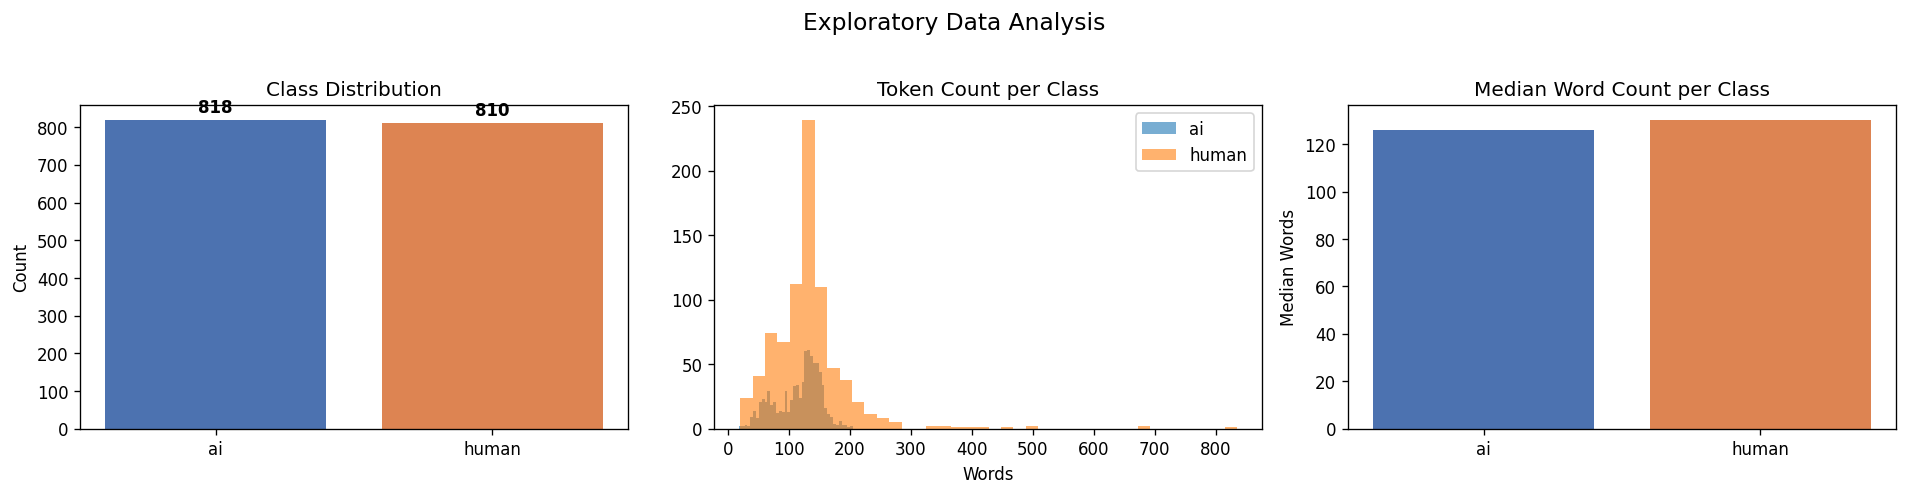

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

#class balance
counts = df['label'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#4C72B0', '#DD8452'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Token length dist
df['word_count'] = df['cleaned'].apply(lambda x: len(x.split()))
for label, grp in df.groupby('label'):
    axes[1].hist(grp['word_count'], bins=40, alpha=0.6, label=label)
axes[1].set_title('Token Count per Class')
axes[1].set_xlabel('Words')
axes[1].legend()

#  Median text length
medians = df.groupby('label')['word_count'].median()
axes[2].bar(medians.index, medians.values, color=['#4C72B0', '#DD8452'])
axes[2].set_title('Median Word Count per Class')
axes[2].set_ylabel('Median Words')

plt.suptitle('Exploratory Data Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

<h1> Train / Test Split </h1>

In [9]:
le = LabelEncoder()
y = le.fit_transform(df['label'])   # ai=0, human=1
X = df['cleaned']

print(f'Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Train class balance — ai: {(y_train==0).sum()}  human: {(y_train==1).sum()}')

Label mapping: {'ai': np.int64(0), 'human': np.int64(1)}
Train: 1,302  |  Test: 326
Train class balance — ai: 654  human: 648


<h1>PART 3- Text Rep Tech</h1>

In [10]:
print("3. Part 3 — Text Representation Techniques")

# 3A. Bag-of-Words (BoW)
#Bag-of-Words (BoW): يقوم بعدّ تكرار الكلمات. تم ضبطه ليأخذ الكلمات المفردة والكلمات الثنائية المترابطة
#ngram_range=(1, 2)       #وبحد أقصى 15,000 كلمة لمنع تضخم المصفوفة.
print("\n[A] Bag-of-Words (BoW)")
bow_vectorizer = CountVectorizer(max_features=15000, ngram_range=(1, 2))
X_bow_train = bow_vectorizer.fit_transform(X_train)
X_bow_test  = bow_vectorizer.transform(X_test)
print(f"    Vocabulary size : {len(bow_vectorizer.vocabulary_):,}")
print(f"    Matrix shape    : {X_bow_train.shape}")

# 3B. TF-IDF
#  TF-IDF: يعطي وزناً للكلمة بناءً على أهميتها؛ الكلمة التي تتكرر كثيراً في نص واحد ولكنها نادرة في باقي النصوص تأخذ وزناً أعلى. الكود يقوم بطباعة أعلى 10 كلمات تميز النصوص بناءً على هذا الوزن.
print("\n[B] TF-IDF")
tfidf_vectorizer = TfidfVectorizer(max_features=15000, ngram_range=(1, 2),
                                   sublinear_tf=True)
X_tfidf_train = tfidf_vectorizer.fit_transform(X_train)
X_tfidf_test  = tfidf_vectorizer.transform(X_test)
print(f"    Vocabulary size : {len(tfidf_vectorizer.vocabulary_):,}")
print(f"    Matrix shape    : {X_tfidf_train.shape}")

# أعلى 10 كلمات بـ TF-IDF
feature_names = tfidf_vectorizer.get_feature_names_out()
mean_tfidf = np.asarray(X_tfidf_train.mean(axis=0)).flatten()
top10_idx = mean_tfidf.argsort()[-10:][::-1]
print(f"    أعلى 10 كلمات (TF-IDF): {list(feature_names[top10_idx])}")

# ── 3C. Word2Vec (trained on our corpus) ─────────────────────
print("\n[C] Word2Vec (trained on Arabic corpus)")
print("    جاري تدريب نموذج Word2Vec...")

# تدريب Word2Vec على نصوص التدريب فقط (لمنع data leakage)
train_tokens = [t.split() for t in X_train]

w2v_model = Word2Vec(
    sentences   = train_tokens,
    vector_size = 150,        # حجم المتجه
    window      = 5,          # حجم النافذة
    min_count   = 2,          # أقل تكرار للكلمة
    workers     = 4,
    epochs      = 15,
    seed        = 42
)
print(f"    حجم المفردات : {len(w2v_model.wv):,} كلمة")
print(f"    حجم المتجه   : {w2v_model.vector_size}")

# دالة حساب متجه النص (متوسط متجهات الكلمات)
def text_to_avg_vector(text, model, size=150):
    tokens = text.split() if isinstance(text, str) else []
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

VEC_SIZE = w2v_model.vector_size
X_w2v_train = np.array([text_to_avg_vector(t, w2v_model, VEC_SIZE) for t in X_train])
X_w2v_test  = np.array([text_to_avg_vector(t, w2v_model, VEC_SIZE) for t in X_test])
print(f"    شكل مصفوفة Word2Vec: {X_w2v_train.shape}")

# مثال: أقرب كلمات لـ "ذكاء"
try:
    similar = w2v_model.wv.most_similar("ذكاء", topn=5)
    print(f"    أقرب كلمات لـ 'ذكاء': {[w for w,_ in similar]}")
except:
    pass

3. Part 3 — Text Representation Techniques

[A] Bag-of-Words (BoW)
    Vocabulary size : 15,000
    Matrix shape    : (1302, 15000)

[B] TF-IDF
    Vocabulary size : 15,000
    Matrix shape    : (1302, 15000)
    أعلى 10 كلمات (TF-IDF): ['علي', 'ان', 'الي', 'الاصطناعي', 'الذكاء', 'الذكاء الاصطناعي', 'او', 'بشكل', 'البيانات', 'يمكن']

[C] Word2Vec (trained on Arabic corpus)
    جاري تدريب نموذج Word2Vec...
    حجم المفردات : 12,098 كلمة
    حجم المتجه   : 150
    شكل مصفوفة Word2Vec: (1302, 150)
    أقرب كلمات لـ 'ذكاء': ['اصطناعي', 'الات', 'مطور', 'مهندس', 'نماذج']


<h1>PART 4- Classical ML Models</h1>
<h3>1- NB - Multinomial</h3>

In [11]:
from sklearn.base import clone

BOW_PARAMS   = dict(max_features=20_000, ngram_range=(1, 2), min_df=2)
TFIDF_PARAMS = dict(max_features=20_000, ngram_range=(1, 2), sublinear_tf=True, min_df=2)

pipelines = {
    'BoW + MultinomialNB':    Pipeline([('vec', CountVectorizer(**BOW_PARAMS)),    ('clf', MultinomialNB())]),
    'TF-IDF + MultinomialNB': Pipeline([('vec', TfidfVectorizer(**TFIDF_PARAMS)), ('clf', MultinomialNB())]),
}

splits_to_try = [3, 5, 10]
best_acc, best_name, best_splits, best_pipe = 0, None, None, None
best_metrics = {}

for n_splits in splits_to_try:
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    for name, pipe in pipelines.items():
        scores = cross_validate(pipe, X_train, y_train, cv=cv,
                        scoring=['f1_macro', 'accuracy', 'roc_auc', 'precision_macro', 'recall_macro'],
                        n_jobs=-1)
        mean_acc = scores['test_accuracy'].mean()
        mean_f1  = scores['test_f1_macro'].mean()
        print(f'splits={n_splits}  {name:<35}'
              f'  Acc={mean_acc:.4f}'
              f'  F1={mean_f1:.4f}'
              f'  AUC={scores["test_roc_auc"].mean():.4f}'
              f'  Prec={scores["test_precision_macro"].mean():.4f}'
              f'  Rec={scores["test_recall_macro"].mean():.4f}')

        mean_auc = scores['test_roc_auc'].mean()
        if round(mean_acc, 4) > round(best_acc, 4) or (round(mean_acc, 4) == round(best_acc, 4) and mean_auc > best_metrics.get('AUC', 0)):
            best_acc, best_name, best_splits, best_pipe = mean_acc, name, n_splits, clone(pipe)
            best_metrics = {
                'F1':   mean_f1,
                'AUC':  mean_auc,
                'Prec': scores['test_precision_macro'].mean(),
                'Rec':  scores['test_recall_macro'].mean(),
            }

print('\n' + '='*60)
print(f'  BEST (by accuracy):  {best_name}  |  splits={best_splits}')
print(f'  CV Accuracy : {best_acc:.4f}')
print(f'  CV F1 Macro : {best_metrics["F1"]:.4f}')
print(f'  CV AUC      : {best_metrics["AUC"]:.4f}')
print(f'  CV Precision: {best_metrics["Prec"]:.4f}')
print(f'  CV Recall   : {best_metrics["Rec"]:.4f}')
print('='*60 + '\n')

best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))
print(f'Test Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Test F1 Macro : {f1_score(y_test, y_pred, average="macro"):.4f}')

splits=3  BoW + MultinomialNB                  Acc=0.8664  F1=0.8655  AUC=0.9150  Prec=0.8757  Rec=0.8660
splits=3  TF-IDF + MultinomialNB               Acc=0.8479  F1=0.8451  AUC=0.9106  Prec=0.8719  Rec=0.8473
splits=5  BoW + MultinomialNB                  Acc=0.8656  F1=0.8645  AUC=0.9180  Prec=0.8767  Rec=0.8652
splits=5  TF-IDF + MultinomialNB               Acc=0.8495  F1=0.8468  AUC=0.9117  Prec=0.8738  Rec=0.8489
splits=10  BoW + MultinomialNB                  Acc=0.8702  F1=0.8690  AUC=0.9163  Prec=0.8814  Rec=0.8699
splits=10  TF-IDF + MultinomialNB               Acc=0.8533  F1=0.8506  AUC=0.9111  Prec=0.8771  Rec=0.8528

  BEST (by accuracy):  BoW + MultinomialNB  |  splits=10
  CV Accuracy : 0.8702
  CV F1 Macro : 0.8690
  CV AUC      : 0.9163
  CV Precision: 0.8814
  CV Recall   : 0.8699

              precision    recall  f1-score   support

          ai       0.84      0.95      0.89       164
       human       0.94      0.82      0.88       162

    accuracy            

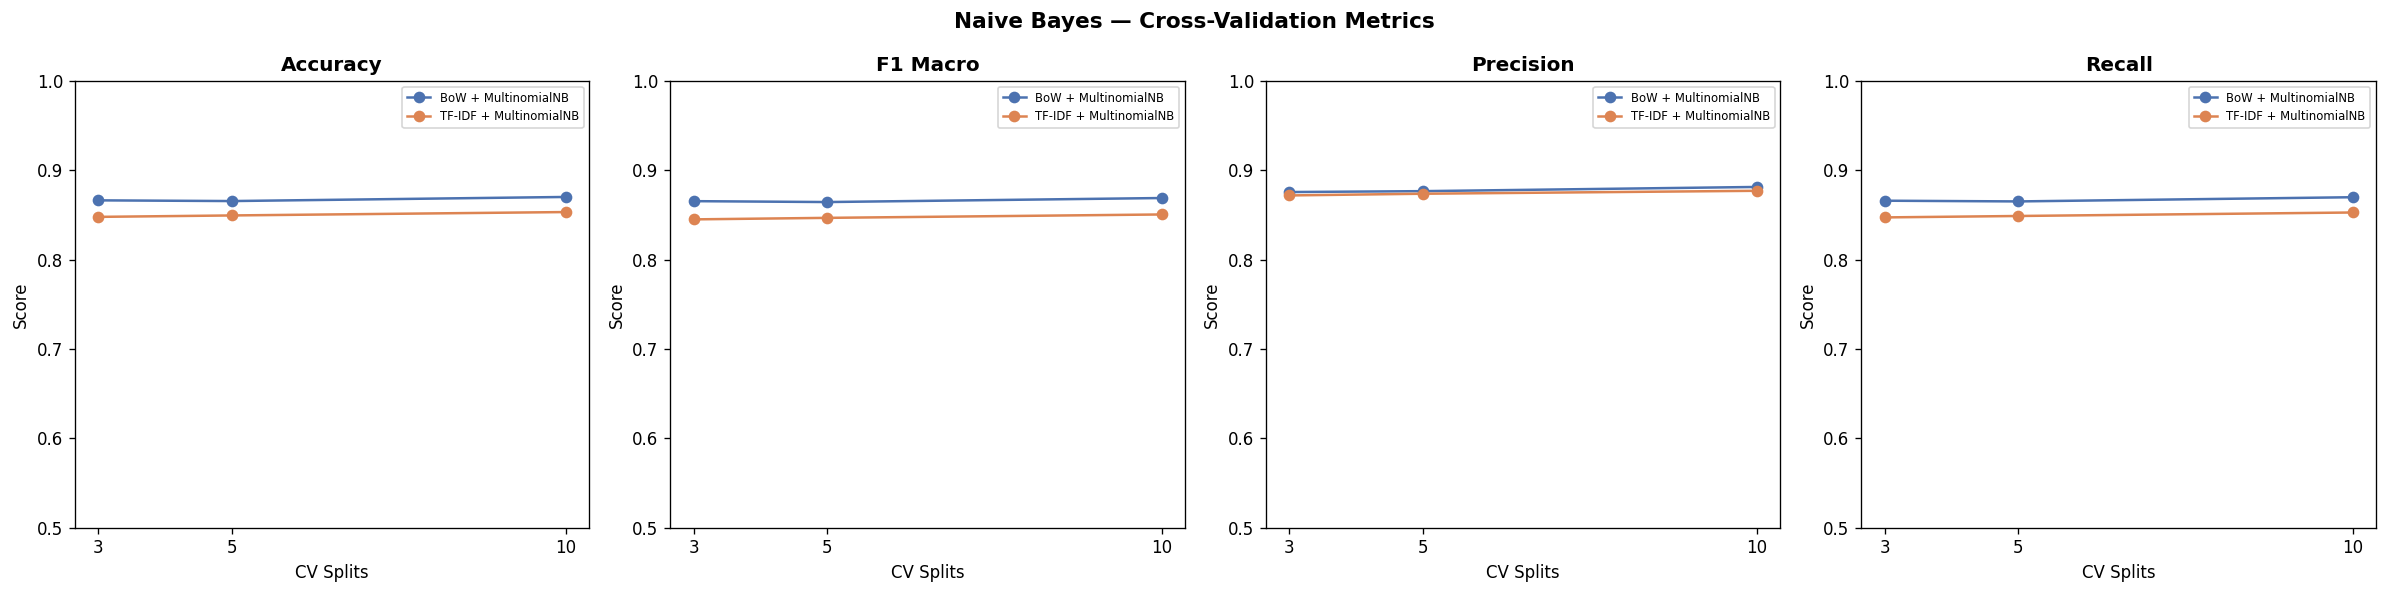

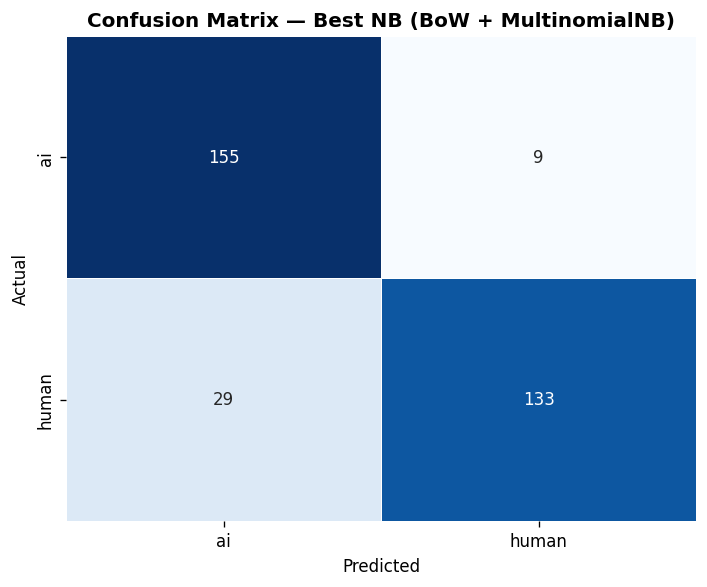

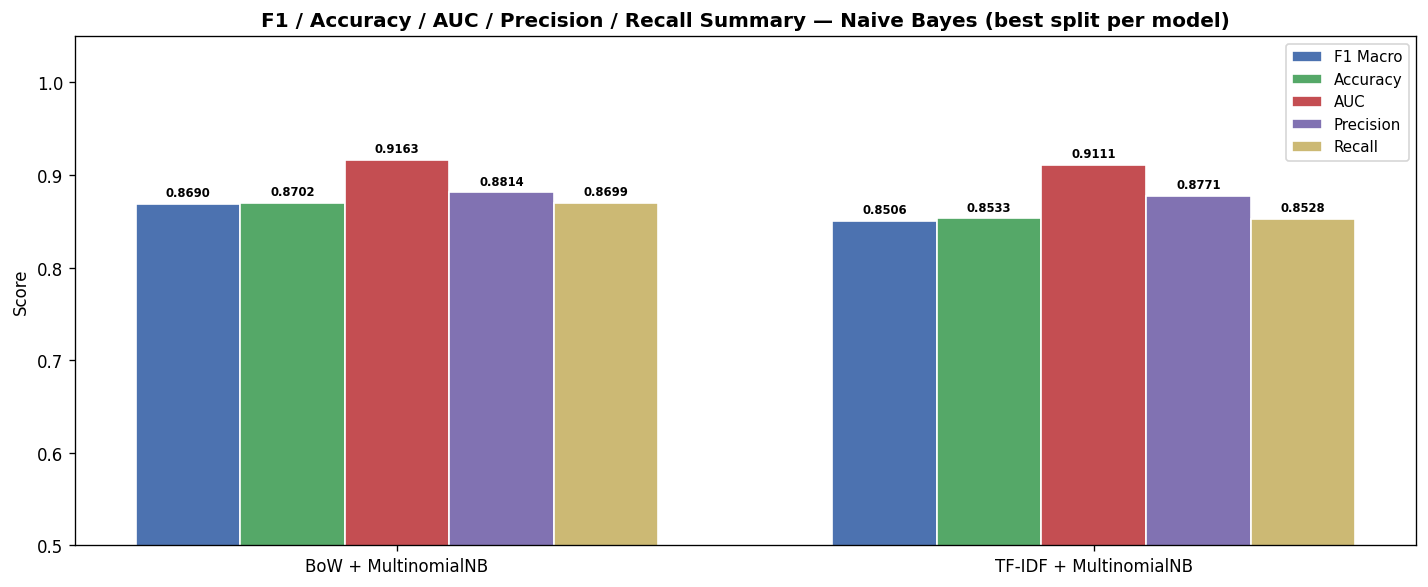

In [12]:
# NB Vizualizations

nb_results = []

for n_splits in splits_to_try:
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    for name, pipe in pipelines.items():
        scores = cross_validate(pipe, X_train, y_train, cv=cv,
                        scoring=['f1_macro', 'accuracy', 'roc_auc', 'precision_macro', 'recall_macro'],
                        n_jobs=-1)
        nb_results.append({
            'Name': name,
            'Splits': n_splits,
            'Accuracy':  round(scores['test_accuracy'].mean(), 4),
            'F1 Macro':  round(scores['test_f1_macro'].mean(), 4),
            'AUC':       round(scores['test_roc_auc'].mean(), 4),
            'Precision': round(scores['test_precision_macro'].mean(), 4),
            'Recall':    round(scores['test_recall_macro'].mean(), 4),
        })

nb_df = pd.DataFrame(nb_results)

# A) CV Metrics across splits
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Naive Bayes — Cross-Validation Metrics", fontsize=13, fontweight='bold')
metrics_to_plot = ['Accuracy', 'F1 Macro', 'Precision', 'Recall']
colors = ['#4C72B0', '#DD8452']

for ax, metric in zip(axes, metrics_to_plot):
    for i, (name, grp) in enumerate(nb_df.groupby('Name')):
        ax.plot(grp['Splits'], grp[metric], marker='o', label=name, color=colors[i])
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel('CV Splits')
    ax.set_ylabel('Score')
    ax.set_xticks(splits_to_try)
    ax.set_ylim(0.5, 1.0)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("nb_cv_metrics.png", dpi=150, bbox_inches='tight')
plt.show()

# B) Confusion Matrix for best NB pipeline
y_pred_nb = best_pipe.predict(X_test)
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, cbar=False)
ax.set_title(f'Confusion Matrix — Best NB ({best_name})', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig("nb_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# C) F1 / Accuracy / AUC / Precision / Recall Summary bar
summary_metrics = ['F1 Macro', 'Accuracy', 'AUC', 'Precision', 'Recall']
best_per_name = nb_df.loc[nb_df.groupby('Name')['F1 Macro'].idxmax()].reset_index(drop=True)

x = np.arange(len(best_per_name))
bar_width = 0.15
metric_colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (metric, color) in enumerate(zip(summary_metrics, metric_colors)):
    bars = ax.bar(x + i * bar_width, best_per_name[metric], bar_width,
                  label=metric, color=color, edgecolor='white')
    for bar, val in zip(bars, best_per_name[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x + bar_width * 2)
ax.set_xticklabels(best_per_name['Name'], fontsize=10)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Score')
ax.set_title('F1 / Accuracy / AUC / Precision / Recall Summary — Naive Bayes (best split per model)', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("nb_f1_summary.png", dpi=150, bbox_inches='tight')
plt.show()

2- SVM

4. Part 4 — Support Vector Machine (RBF Kernel)

تدريب SVM + BoW ...

  [SVM + BoW]
    Accuracy  : 0.8804  (88.04%)
    Precision : 0.8836
    Recall    : 0.8804
    F1-Score  : 0.8801

              precision    recall  f1-score   support

          ai     0.8492    0.9268    0.8863       164
       human     0.9184    0.8333    0.8738       162

    accuracy                         0.8804       326
   macro avg     0.8838    0.8801    0.8800       326
weighted avg     0.8836    0.8804    0.8801       326


تدريب SVM + TF-IDF ...

  [SVM + TF-IDF]
    Accuracy  : 0.8926  (89.26%)
    Precision : 0.8951
    Recall    : 0.8926
    F1-Score  : 0.8924

              precision    recall  f1-score   support

          ai     0.8644    0.9329    0.8974       164
       human     0.9262    0.8519    0.8875       162

    accuracy                         0.8926       326
   macro avg     0.8953    0.8924    0.8924       326
weighted avg     0.8951    0.8926    0.8924       326


تدريب SVM + W

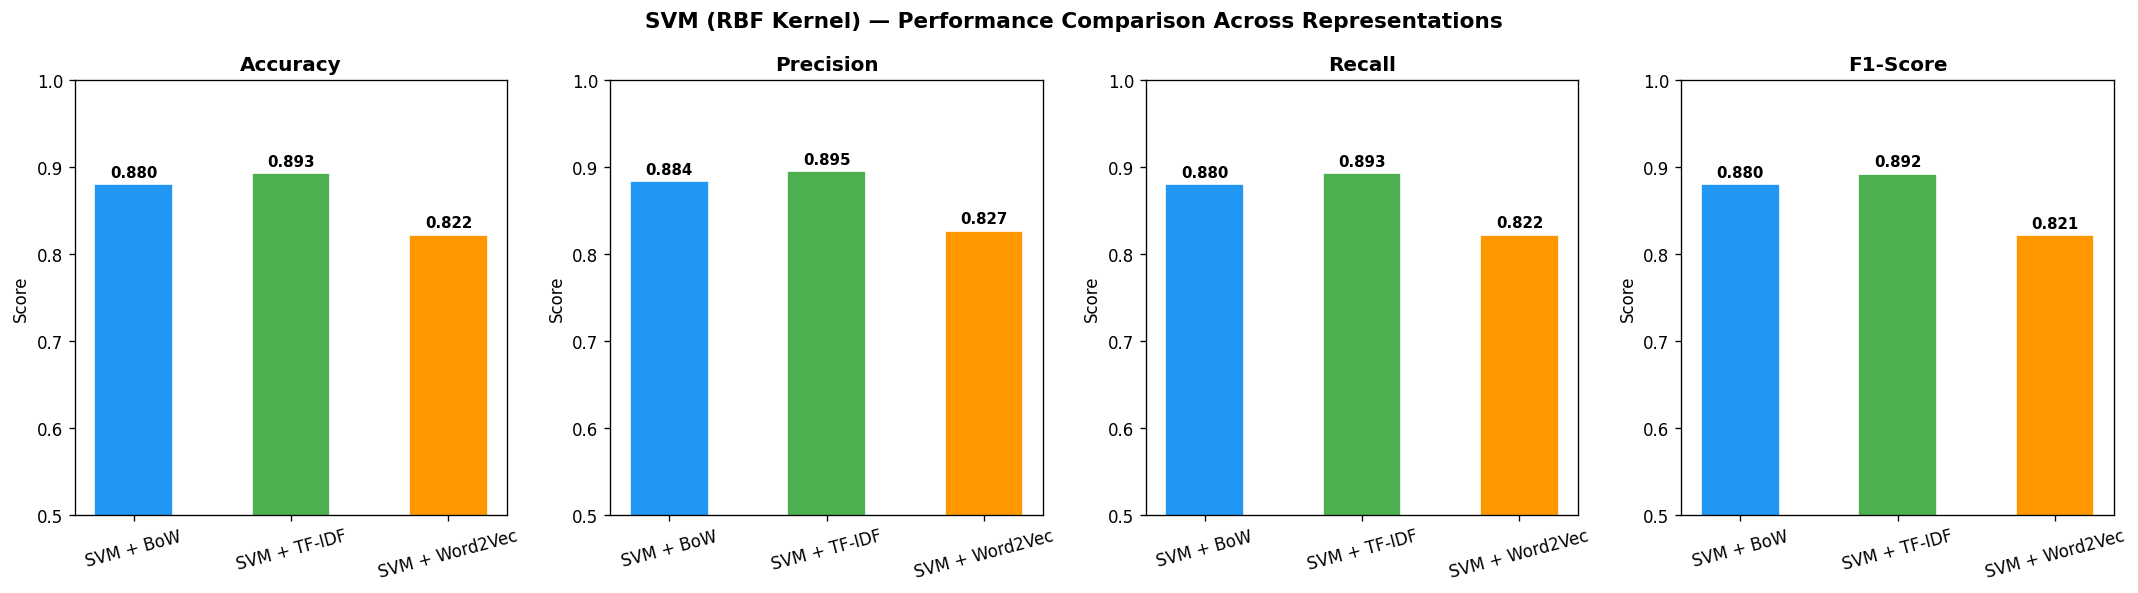

Saved: svm_performance_comparison.png


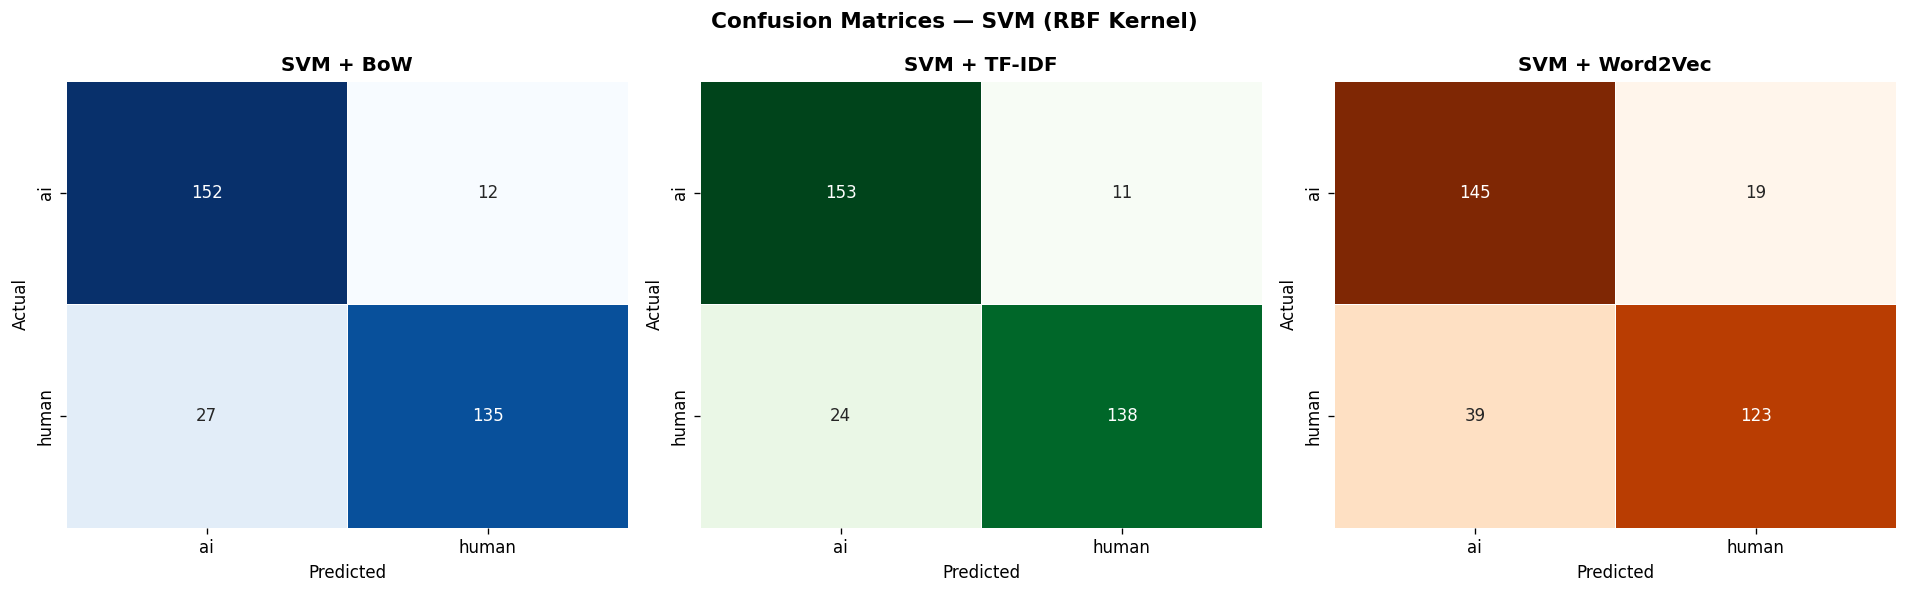

Saved: svm_confusion_matrices.png


In [13]:
# 4. Part 4 — SVM with RBF Kernel
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
from sklearn.svm import SVC

print("4. Part 4 — Support Vector Machine (RBF Kernel)")

def evaluate_model(model, X_test, y_test, name):
    """تقييم النموذج وإرجاع النتائج"""
    y_pred = model.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted")
    rec  = recall_score(y_test, y_pred, average="weighted")
    f1   = f1_score(y_test, y_pred, average="weighted")
    print(f"\n  [{name}]")
    print(f"    Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"    Precision : {prec:.4f}")
    print(f"    Recall    : {rec:.4f}")
    print(f"    F1-Score  : {f1:.4f}")
    print()
    print(classification_report(y_test, y_pred,
                                target_names=le.classes_,
                                digits=4))
    return {
        "Representation" : name,
        "Accuracy"       : round(acc, 4),
        "Precision"      : round(prec, 4),
        "Recall"         : round(rec, 4),
        "F1-Score"       : round(f1, 4),
        "y_pred"         : y_pred
    }

svm_results = []

#  SVM + BoW
print("\nتدريب SVM + BoW ...")
svm_bow = SVC(kernel="rbf", C=10, gamma="scale", random_state=42, probability=True)
svm_bow.fit(X_bow_train, y_train)
res_bow = evaluate_model(svm_bow, X_bow_test, y_test, "SVM + BoW")
svm_results.append(res_bow)

#  SVM + TF-IDF
print("\nتدريب SVM + TF-IDF ...")
svm_tfidf = SVC(kernel="rbf", C=10, gamma="scale", random_state=42, probability=True)
svm_tfidf.fit(X_tfidf_train, y_train)
res_tfidf = evaluate_model(svm_tfidf, X_tfidf_test, y_test, "SVM + TF-IDF")
svm_results.append(res_tfidf)

#  SVM + Word2Vec
print("\nتدريب SVM + Word2Vec ...")
svm_w2v = SVC(kernel="rbf", C=10, gamma="scale", random_state=42, probability=True)
svm_w2v.fit(X_w2v_train, y_train)
res_w2v = evaluate_model(svm_w2v, X_w2v_test, y_test, "SVM + Word2Vec")
svm_results.append(res_w2v)


print()
print("5. مقارنة النتائج — SVM with RBF Kernel")

comparison_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != "y_pred"}
    for r in svm_results
])
print(comparison_df.to_string(index=False))


metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
representations = [r["Representation"] for r in svm_results]
colors = ["#2196F3", "#4CAF50", "#FF9800"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("SVM (RBF Kernel) — Performance Comparison Across Representations",
             fontsize=13, fontweight="bold")

for ax, metric in zip(axes, metrics):
    values = [r[metric] for r in svm_results]
    bars = ax.bar(representations, values, color=colors, edgecolor="white",
                  width=0.5)
    ax.set_title(metric, fontweight="bold")
    ax.set_ylim(0.5, 1.0)
    ax.set_ylabel("Score")
    ax.tick_params(axis="x", rotation=15)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("svm_performance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: svm_performance_comparison.png")


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Confusion Matrices — SVM (RBF Kernel)", fontsize=13, fontweight="bold")

for ax, result, color in zip(axes, svm_results, ["Blues", "Greens", "Oranges"]):
    cm = confusion_matrix(y_test, result["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap=color, ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_,
                linewidths=0.5, cbar=False)
    ax.set_title(result["Representation"], fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("svm_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: svm_confusion_matrices.png")


3- DT
4- RF


تدريب Decision Tree + BoW ...

  [Decision Tree + BoW]
    Accuracy  : 0.7577  (75.77%)
    Precision : 0.7577
    Recall    : 0.7577
    F1-Score  : 0.7577

              precision    recall  f1-score   support

          AI     0.7607    0.7561    0.7584       164
       Human     0.7546    0.7593    0.7569       162

    accuracy                         0.7577       326
   macro avg     0.7577    0.7577    0.7577       326
weighted avg     0.7577    0.7577    0.7577       326

تدريب Random Forest + BoW ...

  [Random Forest + BoW]
    Accuracy  : 0.8436  (84.36%)
    Precision : 0.8446
    Recall    : 0.8436
    F1-Score  : 0.8434

              precision    recall  f1-score   support

          AI     0.8266    0.8720    0.8487       164
       Human     0.8627    0.8148    0.8381       162

    accuracy                         0.8436       326
   macro avg     0.8447    0.8434    0.8434       326
weighted avg     0.8446    0.8436    0.8434       326


تدريب Decision Tree + TF-IDF

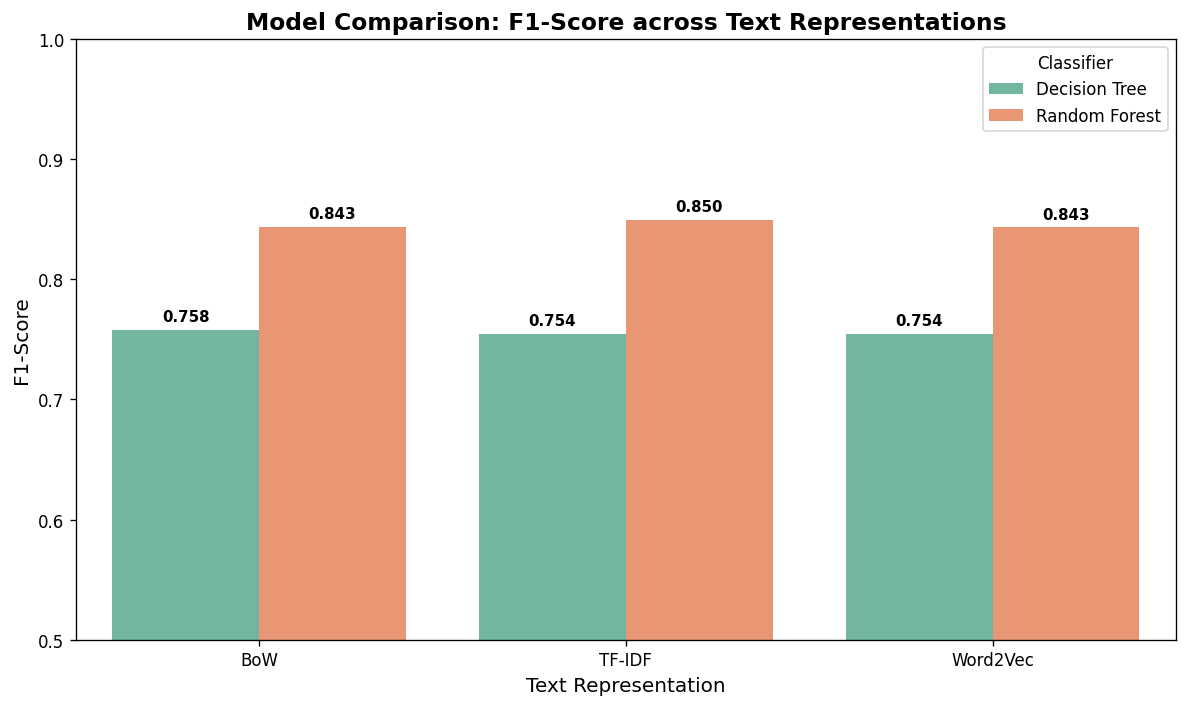

Saved: models_f1_comparison.png


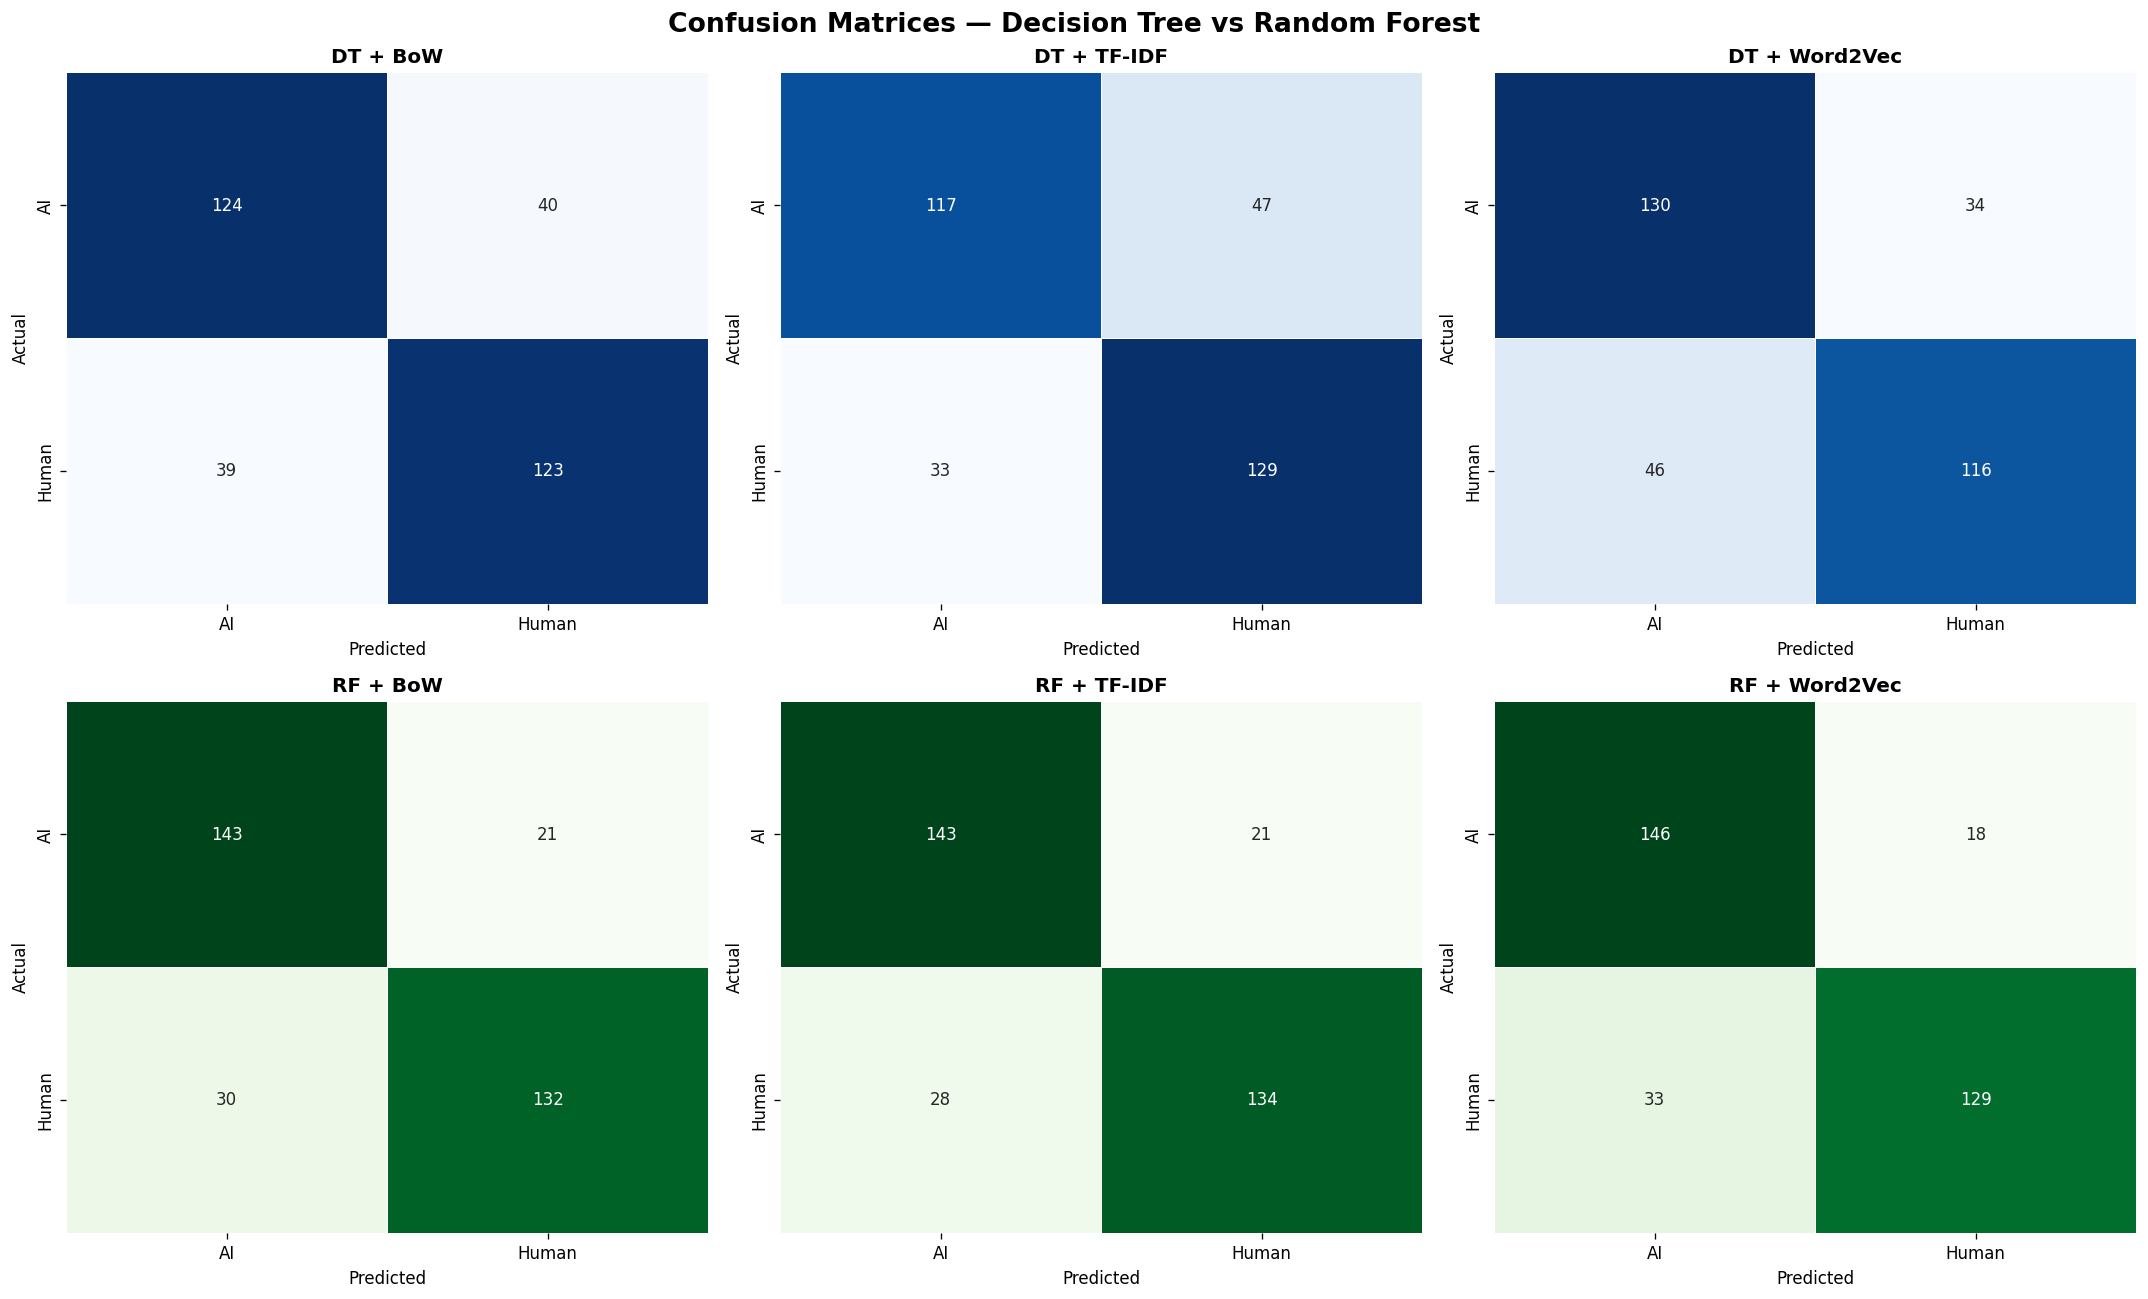

Saved: all_confusion_matrices.png

  : classification_results.csv

 :
        : Random Forest
    : TF-IDF
  Accuracy  : 0.8497 (84.97%)
  F1-Score  : 0.8496


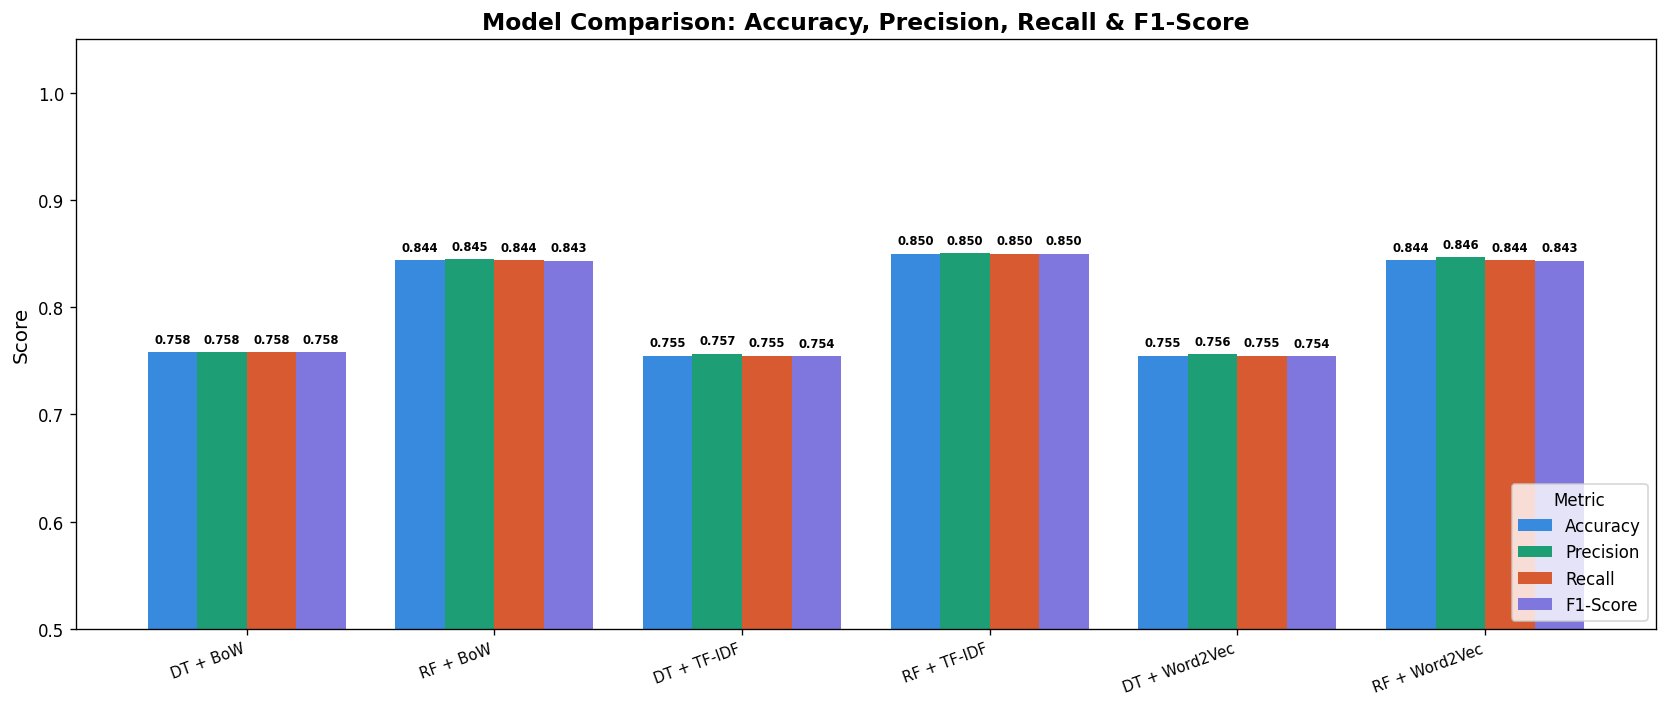

Saved: all_metrics_comparison.png


In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

def evaluate_model(model, X_test, y_test, model_name, rep_name):

    y_pred = model.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted")
    rec  = recall_score(y_test, y_pred, average="weighted")
    f1   = f1_score(y_test, y_pred, average="weighted")

    full_name = f"{model_name} + {rep_name}"
    print(f"\n  [{full_name}]")
    print(f"    Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"    Precision : {prec:.4f}")
    print(f"    Recall    : {rec:.4f}")
    print(f"    F1-Score  : {f1:.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=['AI', 'Human'], digits=4))

    return {
        "Model"          : model_name,
        "Representation" : rep_name,
        "Accuracy"       : round(acc, 4),
        "Precision"      : round(prec, 4),
        "Recall"         : round(rec, 4),
        "F1-Score"       : round(f1, 4),
        "y_pred"         : y_pred
    }

tree_results = []

#
tasks = [
    ("BoW", X_bow_train, X_bow_test),
    ("TF-IDF", X_tfidf_train, X_tfidf_test),
    ("Word2Vec", X_w2v_train, X_w2v_test)
]

for rep_name, x_tr, x_te in tasks:
    # 1.  Decision Tree
    print(f"\nتدريب Decision Tree + {rep_name} ...")
    dt = DecisionTreeClassifier(
        criterion='gini',
        max_depth=10,
        min_samples_split=3,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42
    )
    dt.fit(x_tr, y_train)
    tree_results.append(evaluate_model(dt, x_te, y_test, "Decision Tree", rep_name))

    print(f"تدريب Random Forest + {rep_name} ...")
    rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
    rf.fit(x_tr, y_train)
    tree_results.append(evaluate_model(rf, x_te, y_test, "Random Forest", rep_name))

# 5.
print()
print("5.   — Decision Tree vs Random Forest")

comparison_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != "y_pred"}
    for r in tree_results
])
#
comparison_df = comparison_df.sort_values(by=["Representation", "Model"]).reset_index(drop=True)
print(comparison_df.to_string(index=False))




plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_df, x="Representation", y="F1-Score", hue="Model", palette="Set2")
plt.ylim(0.5, 1.0)
plt.title("Model Comparison: F1-Score across Text Representations", fontsize=14, fontweight="bold")
plt.xlabel("Text Representation", fontsize=12)
plt.ylabel("F1-Score", fontsize=12)
plt.legend(title="Classifier")
for p in plt.gca().patches:
    if p.get_height() > 0:
        plt.gca().annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.savefig("models_f1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: models_f1_comparison.png")

#  (Confusion Matrices)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Confusion Matrices — Decision Tree vs Random Forest", fontsize=16, fontweight="bold")

#
dt_res = [r for r in tree_results if r["Model"] == "Decision Tree"]
rf_res = [r for r in tree_results if r["Model"] == "Random Forest"]

for i, res in enumerate(dt_res):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0, i],
                xticklabels=['AI', 'Human'], yticklabels=['AI', 'Human'], linewidths=0.5, cbar=False)
    axes[0, i].set_title(f"DT + {res['Representation']}", fontweight="bold")
    axes[0, i].set_xlabel("Predicted")
    axes[0, i].set_ylabel("Actual")

for i, res in enumerate(rf_res):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", ax=axes[1, i],
                xticklabels=['AI', 'Human'], yticklabels=['AI', 'Human'], linewidths=0.5, cbar=False)
    axes[1, i].set_title(f"RF + {res['Representation']}", fontweight="bold")
    axes[1, i].set_xlabel("Predicted")
    axes[1, i].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("all_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: all_confusion_matrices.png")


comparison_df.to_csv("classification_results.csv", index=False, encoding="utf-8-sig")
print()
print("=" * 60)
print("  : classification_results.csv")
print("=" * 60)
print()

best_idx = comparison_df["F1-Score"].idxmax()
best_model = comparison_df.loc[best_idx]
print(f" :")
print(f"        : {best_model['Model']}")
print(f"    : {best_model['Representation']}")
print(f"  Accuracy  : {best_model['Accuracy']:.4f} ({best_model['Accuracy']*100:.2f}%)")
print(f"  F1-Score  : {best_model['F1-Score']:.4f}")

#  Grouped bar chart(acc, Precision, Recall, F1)
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
model_labels = [f"{r['Model'].replace('Decision Tree','DT').replace('Random Forest','RF')} + {r['Representation']}"
                for r in tree_results]

x = np.arange(len(model_labels))
width = 0.2
colors = ["#378ADD", "#1D9E75", "#D85A30", "#7F77DD"]

fig, ax = plt.subplots(figsize=(14, 6))

for i, metric in enumerate(metrics):
    values = [r[metric] for r in tree_results]
    bars = ax.bar(x + i * width, values, width, label=metric, color=colors[i])
    for bar in bars:
        if bar.get_height() > 0:
            ax.annotate(f"{bar.get_height():.3f}",
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                        xytext=(0, 4), textcoords="offset points",
                        ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_labels, rotation=20, ha='right', fontsize=9)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Model Comparison: Accuracy, Precision, Recall & F1-Score", fontsize=14, fontweight="bold")
ax.legend(title="Metric", loc="lower right")
plt.tight_layout()
plt.savefig("all_metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: all_metrics_comparison.png")


<h3>5 - AdaBoost </h3>

In [15]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.base import clone

BOW_PARAMS   = dict(max_features=20_000, ngram_range=(1, 2), min_df=2)
TFIDF_PARAMS = dict(max_features=20_000, ngram_range=(1, 2), sublinear_tf=True, min_df=2)

pipelines = {
    'BoW + AdaBoost':    Pipeline([('vec', CountVectorizer(**BOW_PARAMS)),    ('clf', AdaBoostClassifier(random_state=42))]),
    'TF-IDF + AdaBoost': Pipeline([('vec', TfidfVectorizer(**TFIDF_PARAMS)), ('clf', AdaBoostClassifier(random_state=42))]),
}

splits_to_try = [3, 5, 10]
ada_best_acc, ada_best_name, ada_best_splits, ada_best_pipe = 0, None, None, None
ada_best_metrics = {}
ada_best_is_w2v = False

# BoW & TF-IDF pipelines
for n_splits in splits_to_try:
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    for name, pipe in pipelines.items():
        scores = cross_validate(pipe, X_train, y_train, cv=cv,
                        scoring=['f1_macro', 'accuracy', 'roc_auc', 'precision_macro', 'recall_macro'],
                        n_jobs=-1)
        mean_acc = scores['test_accuracy'].mean()
        mean_auc = scores['test_roc_auc'].mean()
        mean_f1  = scores['test_f1_macro'].mean()
        print(f'splits={n_splits}  {name:<35}'
              f'  Acc={mean_acc:.4f}'
              f'  F1={mean_f1:.4f}'
              f'  AUC={mean_auc:.4f}'
              f'  Prec={scores["test_precision_macro"].mean():.4f}'
              f'  Rec={scores["test_recall_macro"].mean():.4f}')
        if round(mean_acc, 4) > round(ada_best_acc, 4) or (round(mean_acc, 4) == round(ada_best_acc, 4) and mean_auc > ada_best_metrics.get('AUC', 0)):
            ada_best_acc, ada_best_name, ada_best_splits, ada_best_pipe = mean_acc, name, n_splits, clone(pipe)
            ada_best_is_w2v = False
            ada_best_metrics = {'F1': mean_f1, 'AUC': mean_auc,
                            'Prec': scores['test_precision_macro'].mean(),
                            'Rec':  scores['test_recall_macro'].mean()}

# Word2Vec pipelines
for n_splits in splits_to_try:
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    w2v_clf = AdaBoostClassifier(random_state=42)
    scores = cross_validate(w2v_clf, X_w2v_train, y_train, cv=cv,
                    scoring=['f1_macro', 'accuracy', 'roc_auc', 'precision_macro', 'recall_macro'],
                    n_jobs=-1)
    mean_acc = scores['test_accuracy'].mean()
    mean_auc = scores['test_roc_auc'].mean()
    mean_f1  = scores['test_f1_macro'].mean()
    print(f'splits={n_splits}  {"W2V + AdaBoost":<35}'
          f'  Acc={mean_acc:.4f}'
          f'  F1={mean_f1:.4f}'
          f'  AUC={mean_auc:.4f}'
          f'  Prec={scores["test_precision_macro"].mean():.4f}'
          f'  Rec={scores["test_recall_macro"].mean():.4f}')
    if round(mean_acc, 4) > round(ada_best_acc, 4) or (round(mean_acc, 4) == round(ada_best_acc, 4) and mean_auc > ada_best_metrics.get('AUC', 0)):
        ada_best_acc, ada_best_name, ada_best_splits, ada_best_pipe = mean_acc, 'W2V + AdaBoost', n_splits, clone(w2v_clf)
        ada_best_is_w2v = True
        ada_best_metrics = {'F1': mean_f1, 'AUC': mean_auc,
                        'Prec': scores['test_precision_macro'].mean(),
                        'Rec':  scores['test_recall_macro'].mean()}

print(f'  BEST (by accuracy):  {ada_best_name}  |  splits={ada_best_splits}')
print(f'  CV Accuracy : {ada_best_acc:.4f}')
print(f'  CV F1 Macro : {ada_best_metrics["F1"]:.4f}')
print(f'  CV AUC      : {ada_best_metrics["AUC"]:.4f}')
print(f'  CV Precision: {ada_best_metrics["Prec"]:.4f}')
print(f'  CV Recall   : {ada_best_metrics["Rec"]:.4f}')

# Train & evaluate best
if ada_best_is_w2v:
    ada_best_pipe.fit(X_w2v_train, y_train)
    y_pred = ada_best_pipe.predict(X_w2v_test)
else:
    ada_best_pipe.fit(X_train, y_train)
    y_pred = ada_best_pipe.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))
print(f'Test Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Test F1 Macro : {f1_score(y_test, y_pred, average="macro"):.4f}')

splits=3  BoW + AdaBoost                       Acc=0.7888  F1=0.7884  AUC=0.8637  Prec=0.7911  Rec=0.7889
splits=3  TF-IDF + AdaBoost                    Acc=0.7965  F1=0.7960  AUC=0.8721  Prec=0.7997  Rec=0.7966
splits=5  BoW + AdaBoost                       Acc=0.7873  F1=0.7868  AUC=0.8650  Prec=0.7897  Rec=0.7874
splits=5  TF-IDF + AdaBoost                    Acc=0.8057  F1=0.8055  AUC=0.8705  Prec=0.8076  Rec=0.8059
splits=10  BoW + AdaBoost                       Acc=0.7880  F1=0.7877  AUC=0.8646  Prec=0.7904  Rec=0.7882
splits=10  TF-IDF + AdaBoost                    Acc=0.7942  F1=0.7936  AUC=0.8711  Prec=0.7977  Rec=0.7944
splits=3  W2V + AdaBoost                       Acc=0.7680  F1=0.7671  AUC=0.8436  Prec=0.7716  Rec=0.7678
splits=5  W2V + AdaBoost                       Acc=0.7811  F1=0.7806  AUC=0.8530  Prec=0.7834  Rec=0.7810
splits=10  W2V + AdaBoost                       Acc=0.7588  F1=0.7574  AUC=0.8371  Prec=0.7648  Rec=0.7585
  BEST (by accuracy):  TF-IDF + AdaBoost  |

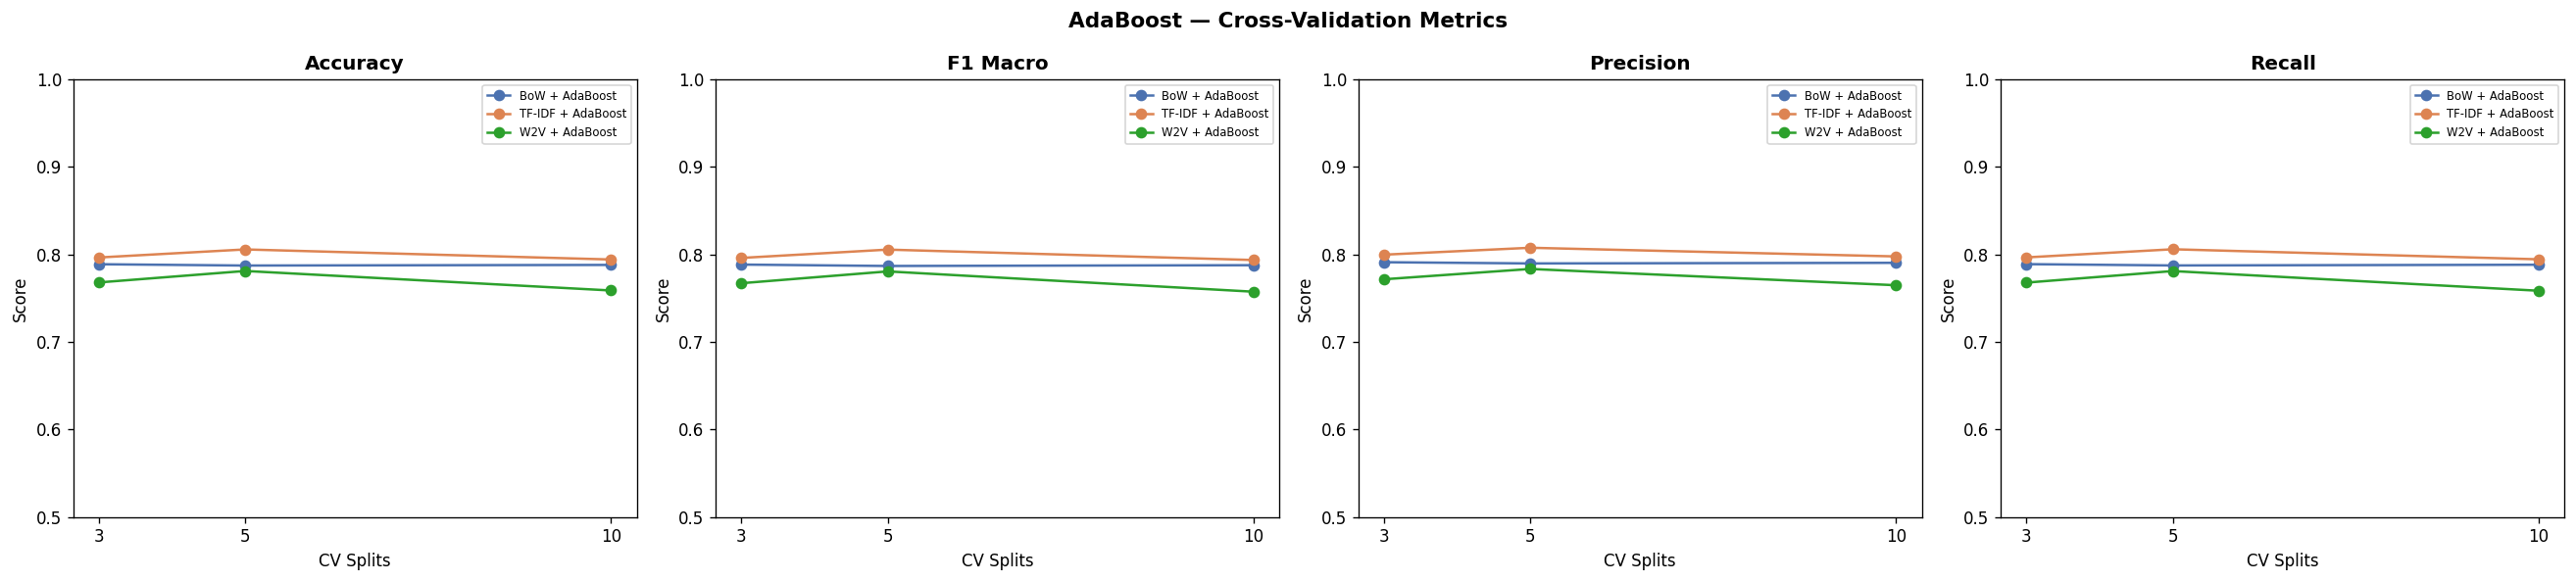

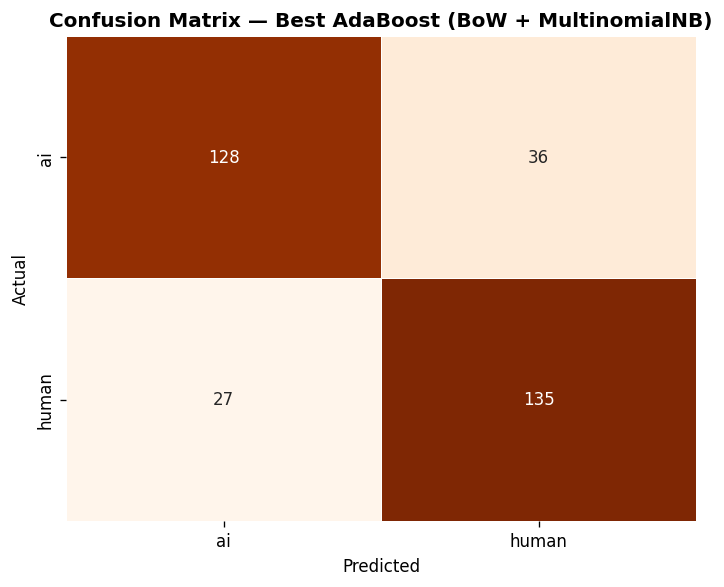

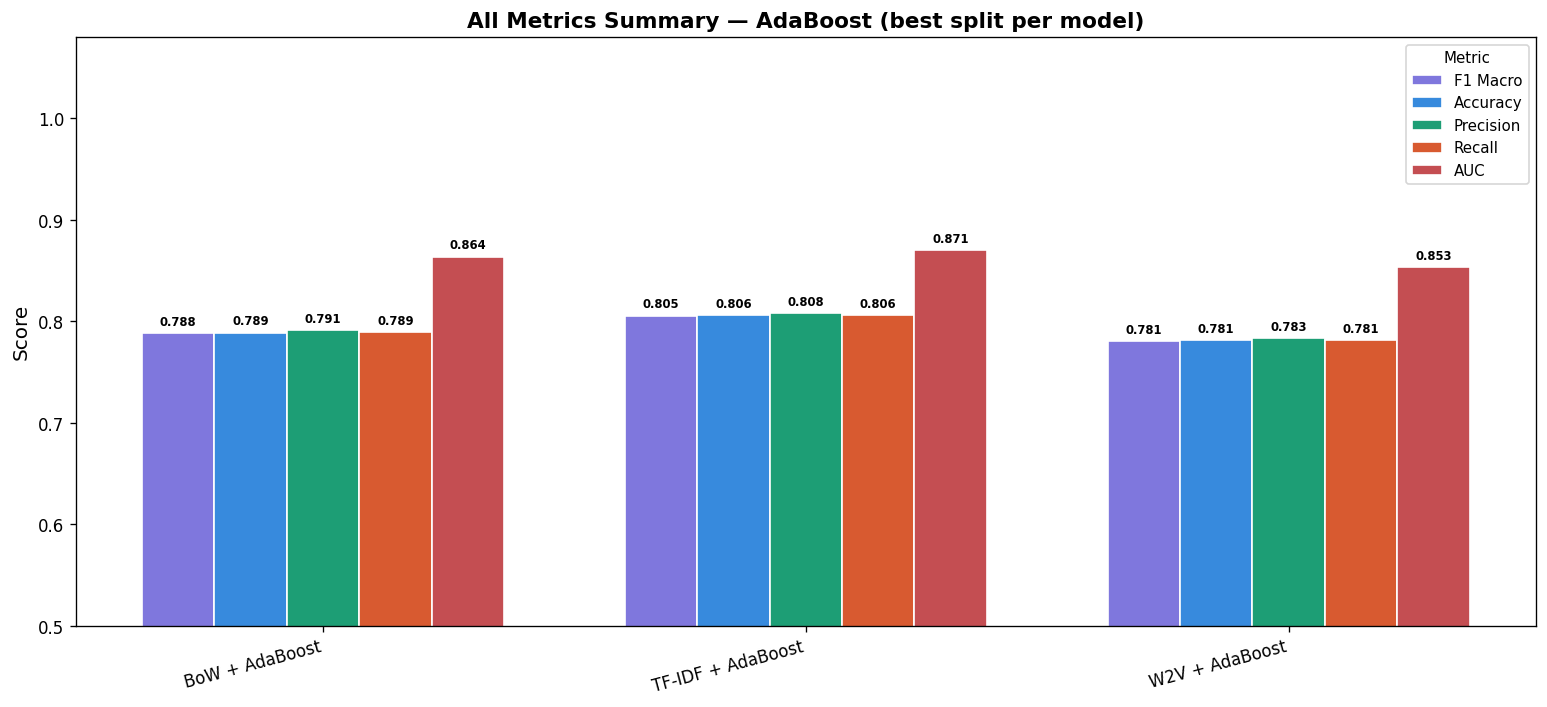

Saved: ada_all_metrics_summary.png


In [16]:
# AdaBoost Visualizations

ada_results = []

for n_splits in splits_to_try:
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    for name, pipe in pipelines.items():
        scores = cross_validate(pipe, X_train, y_train, cv=cv,
                        scoring=['f1_macro', 'accuracy', 'roc_auc', 'precision_macro', 'recall_macro'],
                        n_jobs=-1)
        ada_results.append({
            'Name': name, 'Splits': n_splits,
            'Accuracy':  round(scores['test_accuracy'].mean(), 4),
            'F1 Macro':  round(scores['test_f1_macro'].mean(), 4),
            'AUC':       round(scores['test_roc_auc'].mean(), 4),
            'Precision': round(scores['test_precision_macro'].mean(), 4),
            'Recall':    round(scores['test_recall_macro'].mean(), 4),
        })
    # W2V row
    scores_w2v = cross_validate(w2v_clf, X_w2v_train, y_train, cv=cv,
                    scoring=['f1_macro', 'accuracy', 'roc_auc', 'precision_macro', 'recall_macro'],
                    n_jobs=-1)
    ada_results.append({
        'Name': 'W2V + AdaBoost', 'Splits': n_splits,
        'Accuracy':  round(scores_w2v['test_accuracy'].mean(), 4),
        'F1 Macro':  round(scores_w2v['test_f1_macro'].mean(), 4),
        'AUC':       round(scores_w2v['test_roc_auc'].mean(), 4),
        'Precision': round(scores_w2v['test_precision_macro'].mean(), 4),
        'Recall':    round(scores_w2v['test_recall_macro'].mean(), 4),
    })

ada_df = pd.DataFrame(ada_results)
ada_colors = ['#4C72B0', '#DD8452', '#2ca02c']

# A) CV Metrics across splits
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle("AdaBoost — Cross-Validation Metrics", fontsize=13, fontweight='bold')

for ax, metric in zip(axes, ['Accuracy', 'F1 Macro', 'Precision', 'Recall']):
    for i, (name, grp) in enumerate(ada_df.groupby('Name')):
        ax.plot(grp['Splits'], grp[metric], marker='o', label=name, color=ada_colors[i])
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel('CV Splits')
    ax.set_ylabel('Score')
    ax.set_xticks(splits_to_try)
    ax.set_ylim(0.5, 1.0)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("ada_cv_metrics.png", dpi=150, bbox_inches='tight')
plt.show()

# B) Confusion Matrix for best AdaBoost
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, cbar=False)
ax.set_title(f'Confusion Matrix — Best AdaBoost ({best_name})', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig("ada_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# C) F1 / Accuracy / Precision / Recall / AUC Summary bar
summary_metrics = ['F1 Macro', 'Accuracy', 'Precision', 'Recall', 'AUC']
metric_colors   = ['#7F77DD', '#378ADD', '#1D9E75', '#D85A30', '#C44E52']
best_per_ada = ada_df.loc[ada_df.groupby('Name')['F1 Macro'].idxmax()].reset_index(drop=True)

x = np.arange(len(best_per_ada))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(13, 6))
for i, (metric, color) in enumerate(zip(summary_metrics, metric_colors)):
    bars = ax.bar(x + i * bar_width, best_per_ada[metric], bar_width,
                  label=metric, color=color, edgecolor='white')
    for bar, val in zip(bars, best_per_ada[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x + bar_width * 2)
ax.set_xticklabels(best_per_ada['Name'], fontsize=10, rotation=15, ha='right')
ax.set_ylim(0.5, 1.08)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('All Metrics Summary — AdaBoost (best split per model)', fontsize=13, fontweight='bold')
ax.legend(title='Metric', fontsize=9, title_fontsize=9)
plt.tight_layout()
plt.savefig("ada_all_metrics_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ada_all_metrics_summary.png")

<h1>PART 5- FNN</h1>

Train: 1,302  |  Test: 326
num_classes: 2
TF-IDF Shape: (1302, 5000)
Word2Vec Shape: (1302, 150)
Final Shape: (1302, 5150)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     2,637,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,801,794 (10.69 MB)

 Trainable params: 2,801,794 (10.69 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 195ms/step - accuracy: 0.6277 - loss: 0.6499 - val_accuracy: 0.7634 - val_loss: 0.5642
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8386 - loss: 0.4193 - val_accuracy: 0.8473 - val_loss: 0.4197
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9112 - loss: 0.2370 - val_accuracy: 0.8855 - val_loss: 0.3794
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9718 - loss: 0.1079 - val_accuracy: 0.8855 - val_loss: 0.3572
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9829 - loss: 0.0476 - val_accuracy: 0.8626 - val_loss: 0.5712
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9898 - loss: 0.0252 - val_accuracy: 0.8702 - val_loss: 0.5564
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9923 - loss: 0.0199 - val_accuracy: 0.8550 - val_loss: 0.4617

Test Accuracy: 0.8804
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
              precision    recall  f1-score   support

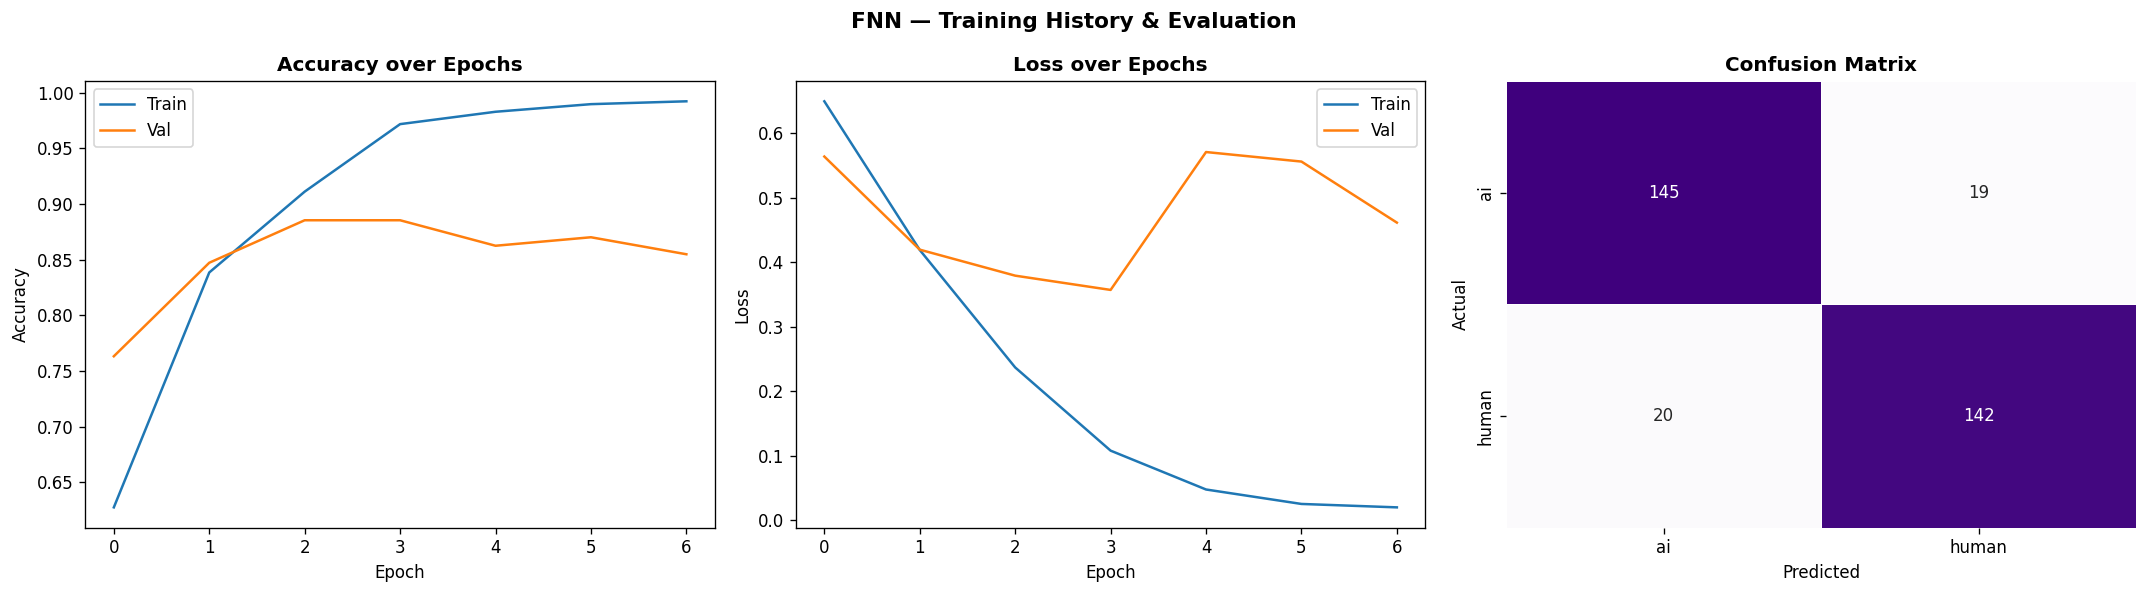

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


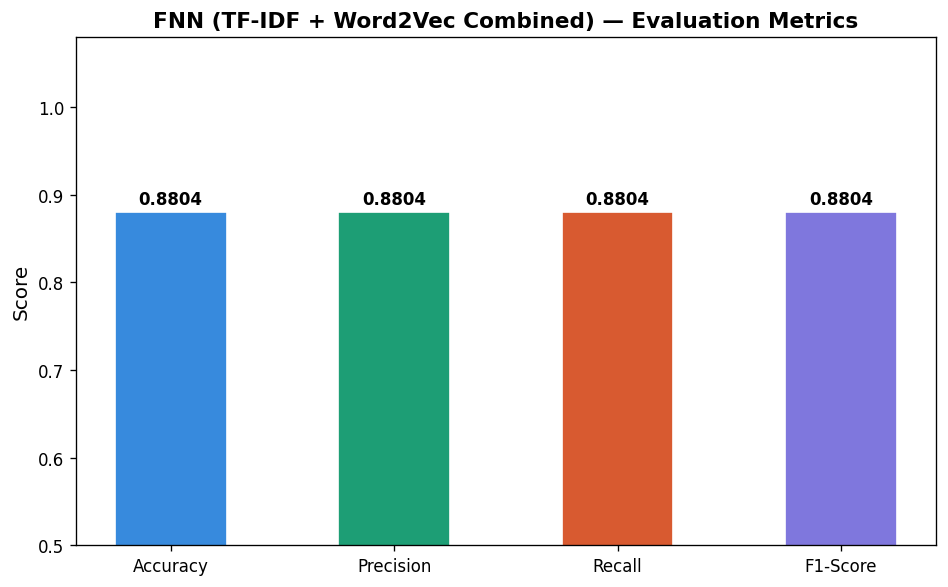

Saved: fnn_all_metrics_comparison.png


In [17]:
# Feed-Forward Neural Network (FNN)
#TF-IDF + Averaged Word2Vec Features

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

#  Labels
le = LabelEncoder()
y_all = le.fit_transform(df['label'])

X_fnn = df['cleaned']
X_fnn_train, X_fnn_test, y_fnn_train_int, y_fnn_test_int = train_test_split(
    X_fnn, y_all, test_size=0.2, random_state=42, stratify=y_all
)

num_classes = len(np.unique(y_all))
y_fnn_train = to_categorical(y_fnn_train_int, num_classes=num_classes)
y_fnn_test  = to_categorical(y_fnn_test_int,  num_classes=num_classes)

print(f"Train: {len(X_fnn_train):,}  |  Test: {len(X_fnn_test):,}")
print(f"num_classes: {num_classes}")

#  TF-IDF Features
fnn_tfidf = TfidfVectorizer(max_features=5000)
X_fnn_train_tfidf = fnn_tfidf.fit_transform(X_fnn_train).toarray()
X_fnn_test_tfidf  = fnn_tfidf.transform(X_fnn_test).toarray()
print("TF-IDF Shape:", X_fnn_train_tfidf.shape)

bow_vectorizer = CountVectorizer(max_features=5000, ngram_range=(1, 2))
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True)
#  Word2Vec Features
# Train Word2Vec on text tokens (not labels)
fnn_train_tokens = [t.split() for t in X_fnn_train]

fnn_w2v = w2v_model = Word2Vec(
    sentences   = train_tokens,
    vector_size = 150,
    window      = 2,
    min_count   = 2,
    workers     = 4,
    epochs      = 15,
    seed        = 42
)

def average_word_vectors(tokens, model, vector_size):
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)

fnn_test_tokens = [t.split() for t in X_fnn_test]

X_fnn_train_w2v = np.array([average_word_vectors(t, fnn_w2v, 150) for t in fnn_train_tokens])
X_fnn_test_w2v  = np.array([average_word_vectors(t, fnn_w2v, 150) for t in fnn_test_tokens])
print("Word2Vec Shape:", X_fnn_train_w2v.shape)

#  Combine Features
X_fnn_train_combined = np.hstack((X_fnn_train_tfidf, X_fnn_train_w2v))
X_fnn_test_combined  = np.hstack((X_fnn_test_tfidf,  X_fnn_test_w2v))
print("Final Shape:", X_fnn_train_combined.shape)

#  Build Model
fnn_model = Sequential([
    Dense(512, activation='relu', input_shape=(X_fnn_train_combined.shape[1],)),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

fnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fnn_model.summary()

#  Train
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

fnn_history = fnn_model.fit(
    X_fnn_train_combined, y_fnn_train,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop]
)

#  Evaluate
loss, accuracy = fnn_model.evaluate(X_fnn_test_combined, y_fnn_test, verbose=0)
print(f"\nTest Accuracy: {accuracy:.4f}")

y_fnn_pred = np.argmax(fnn_model.predict(X_fnn_test_combined), axis=1)

print(classification_report(y_fnn_test_int, y_fnn_pred, target_names=le.classes_))

#  Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("FNN — Training History & Evaluation", fontsize=13, fontweight='bold')

# Training accuracy
axes[0].plot(fnn_history.history['accuracy'],     label='Train')
axes[0].plot(fnn_history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy over Epochs', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Training loss
axes[1].plot(fnn_history.history['loss'],     label='Train')
axes[1].plot(fnn_history.history['val_loss'], label='Val')
axes[1].set_title('Loss over Epochs', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

# Confusion matrix
cm = confusion_matrix(y_fnn_test_int, y_fnn_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[2],
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, cbar=False)
axes[2].set_title('Confusion Matrix', fontweight='bold')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.savefig("fnn_evaluation.png", dpi=150, bbox_inches='tight')
plt.show()

#Grouped bar chart (F1, acc, Precision, Recall)
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

y_pred_combined = np.argmax(fnn_model.predict(X_fnn_test_combined), axis=1)

metrics = {
    'Accuracy':  round(accuracy_score(y_fnn_test_int, y_pred_combined), 4),
    'Precision': round(precision_score(y_fnn_test_int, y_pred_combined, average='weighted'), 4),
    'Recall':    round(recall_score(y_fnn_test_int, y_pred_combined, average='weighted'), 4),
    'F1-Score':  round(f1_score(y_fnn_test_int, y_pred_combined, average='weighted'), 4),
}

metric_colors = ['#378ADD', '#1D9E75', '#D85A30', '#7F77DD']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(metrics.keys(), metrics.values(), color=metric_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0.5, 1.08)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('FNN (TF-IDF + Word2Vec Combined) — Evaluation Metrics',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("fnn_all_metrics_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fnn_all_metrics_comparison.png")

<h1>PART 6 - Recurrent NN (LSTM & biLSTM)</h1>

In [18]:
from tensorflow.keras.optimizers import Adam

# Tokenization & Padding
MAX_VOCAB  = 20_000
MAX_LEN    = 128

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=MAX_LEN, padding='post', truncating='post')

#  Build Word2Vec Embedding Matrix
word_index = tokenizer.word_index
embedding_matrix = np.zeros((MAX_VOCAB, VEC_SIZE))
for word, i in word_index.items():
    if i < MAX_VOCAB and word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

#  Build Model Function
def build_lstm(bidirectional=False):
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=VEC_SIZE,
                  weights=[embedding_matrix], input_length=MAX_LEN, trainable=True),
        SpatialDropout1D(0.2),
        Bidirectional(LSTM(128, dropout=0.2)) if bidirectional else LSTM(128, dropout=0.2),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=1e-4, clipnorm=1.0), loss='binary_crossentropy', metrics=['accuracy'])
    return model

#  Train & Evaluate
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lstm_results = {}

batch_sizes = [16, 32, 64]

for name, bidirectional in [('LSTM', False), ('BiLSTM', True)]:
    for batch_size in batch_sizes:
        run_name = f'{name} (batch={batch_size})'
        print(f'\nTraining {run_name}...')
        model = build_lstm(bidirectional=bidirectional)
        model.fit(X_train_seq, y_train,
                  epochs=30, batch_size=batch_size,
                  validation_split=0.1,
                  callbacks=[es],
                  verbose=1)

        y_pred = (model.predict(X_test_seq) > 0.5).astype(int).flatten()
        acc = accuracy_score(y_test, y_pred)
        f1  = f1_score(y_test, y_pred, average='macro')
        lstm_results[run_name] = {'model': model, 'acc': acc, 'f1': f1, 'batch_size': batch_size}

        print(f'\n{run_name} Results:')
        print(classification_report(y_test, y_pred, target_names=le.classes_))
        print(f'Accuracy : {acc:.4f}')
        print(f'F1 Macro : {f1:.4f}')

# ── Comparison ────────────────────────────────────────────────────────────────
print(f'{"Model":<25}  {"Accuracy":>10}  {"F1 Macro":>10}')
for name, res in lstm_results.items():
    print(f'{name:<25}  {res["acc"]:>10.4f}  {res["f1"]:>10.4f}')
print('='*55)

best_lstm_name = max(lstm_results, key=lambda x: lstm_results[x]['f1'])
best_lstm      = lstm_results[best_lstm_name]['model']
print(f'\nBest: {best_lstm_name}')




Training LSTM (batch=16)...
Epoch 1/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.4910 - loss: 0.6956 - val_accuracy: 0.4504 - val_loss: 0.6970
Epoch 2/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5192 - loss: 0.6940 - val_accuracy: 0.5267 - val_loss: 0.6942
Epoch 3/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5371 - loss: 0.6878 - val_accuracy: 0.5267 - val_loss: 0.6953
Epoch 4/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5594 - loss: 0.6866 - val_accuracy: 0.5725 - val_loss: 0.6935
Epoch 5/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5790 - loss: 0.6780 - val_accuracy: 0.5573 - val_loss: 0.6925
Epoch 6/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6020 - loss: 0.6712 - val_accuracy: 0.5420 - val_loss: 0.6790
Epoch 7/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6447 - loss: 0.6390 - val_accuracy: 0.6489 - val_loss: 0.6513
Epoch 8/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6806 - loss: 0.61

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
            Model  Accuracy  Precision  Recall  F1-Score
  LSTM (batch=16)    0.8160     0.8171  0.8160    0.8157
  LSTM (batch=32)    0.5123     0.5868  0.5123    0.3716
  LSTM (batch=64)    0.5000     0.4980  0.5000    0.4679
BiLSTM (batch=16)    0.6104     0.6559  0.6104    0.5782
BiLSTM (batch=32)    0.6104     0.6431  0.6104    0.5854
BiLSTM (batch=64)    0.5736     0.6849  0.5736    0.4957


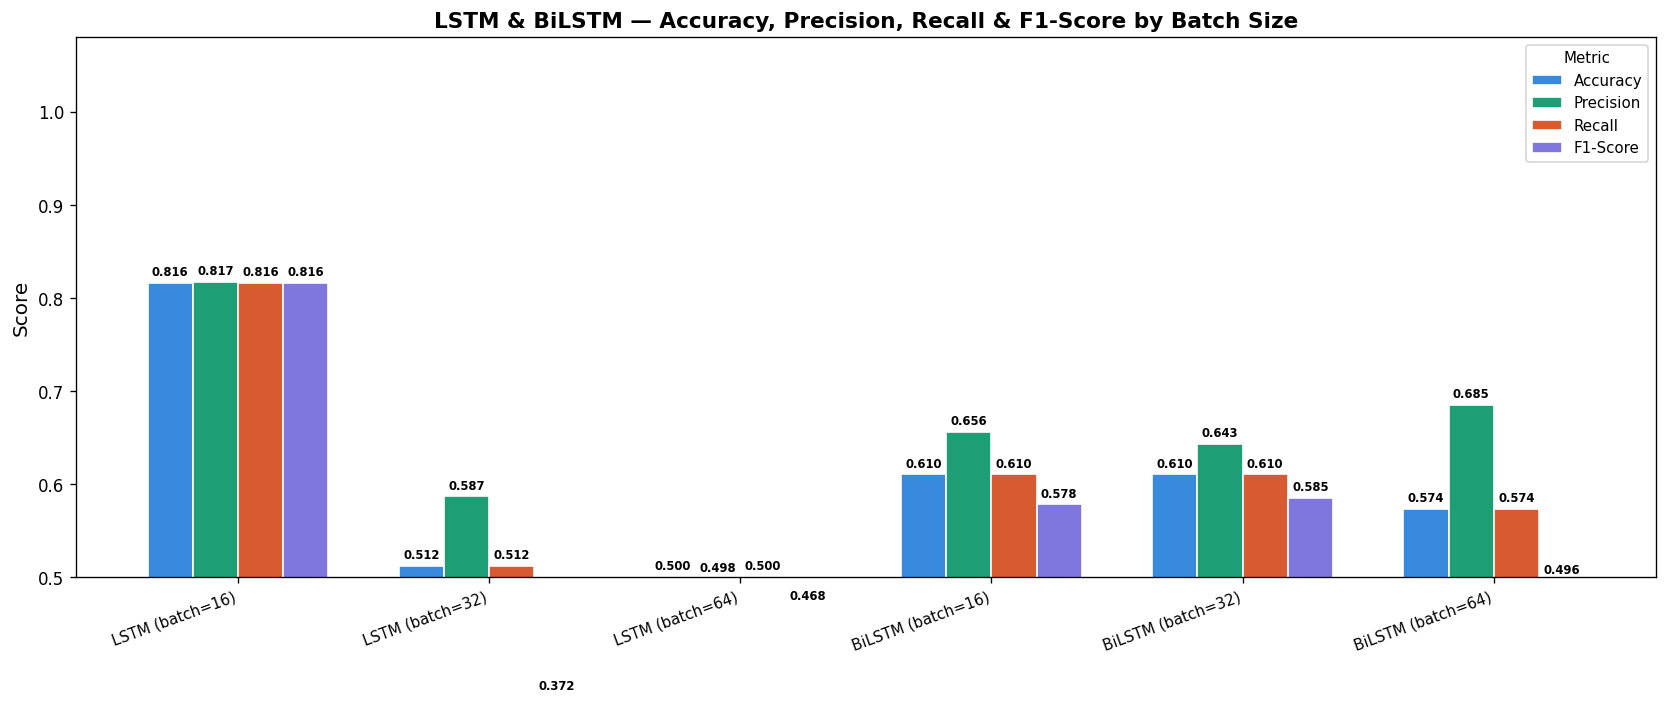

Saved: lstm_all_metrics_comparison.png


In [19]:
# Grouped bar chart — LSTM & BiLSTM Metrics by Batch Size
from sklearn.metrics import precision_score, recall_score

lstm_metrics = []
for run_name, res in lstm_results.items():
    y_pred = (res['model'].predict(X_test_seq) > 0.5).astype(int).flatten()
    lstm_metrics.append({
        'Model':     run_name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, average='weighted'), 4),
        'Recall':    round(recall_score(y_test, y_pred, average='weighted'), 4),
        'F1-Score':  round(f1_score(y_test, y_pred, average='weighted'), 4),
    })

lstm_df = pd.DataFrame(lstm_metrics)
print(lstm_df.to_string(index=False))

summary_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metric_colors   = ['#378ADD', '#1D9E75', '#D85A30', '#7F77DD']

x         = np.arange(len(lstm_df))
bar_width  = 0.18

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(summary_metrics, metric_colors)):
    bars = ax.bar(x + i * bar_width, lstm_df[metric], bar_width,
                  label=metric, color=color, edgecolor='white')
    for bar, val in zip(bars, lstm_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(lstm_df['Model'], fontsize=9, rotation=20, ha='right')
ax.set_ylim(0.5, 1.08)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('LSTM & BiLSTM — Accuracy, Precision, Recall & F1-Score by Batch Size',
             fontsize=13, fontweight='bold')
ax.legend(title='Metric', fontsize=9, title_fontsize=9)
plt.tight_layout()
plt.savefig("lstm_all_metrics_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lstm_all_metrics_comparison.png")

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


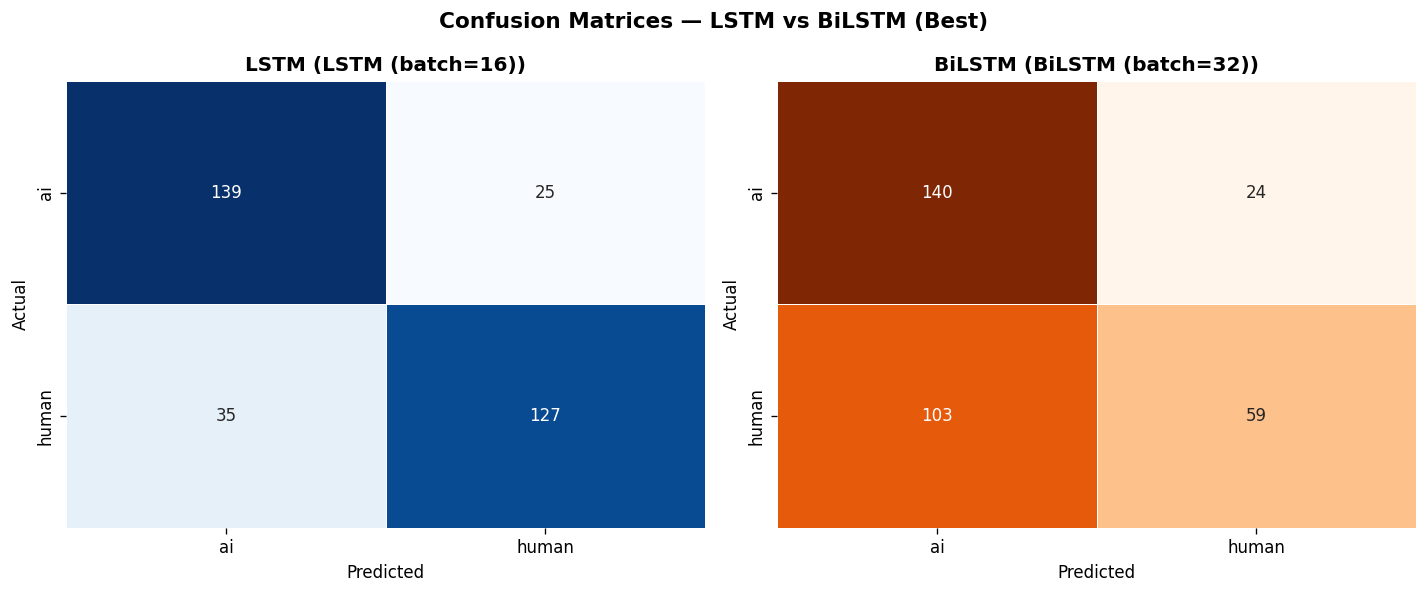

Saved: lstm_bilstm_confusion_matrices.png


In [20]:
# Confusion matrices side by side (best of each)

# Separate LSTM and BiLSTM runs
lstm_only = {k: v for k, v in lstm_results.items() if 'BiLSTM' not in k}
bilstm_only = {k: v for k, v in lstm_results.items() if 'BiLSTM' in k}

# Best per architecture (highest F1)
best_lstm_run = max(lstm_only, key=lambda k: lstm_only[k]['f1'])
best_bilstm_run = max(bilstm_only, key=lambda k: bilstm_only[k]['f1'])

# Get best models
best_lstm_model = lstm_only[best_lstm_run]['model']
best_bilstm_model = bilstm_only[best_bilstm_run]['model']

# Predictions
y_pred_lstm = (best_lstm_model.predict(X_test_seq) > 0.5).astype(int).flatten()
y_pred_bilstm = (best_bilstm_model.predict(X_test_seq) > 0.5).astype(int).flatten()

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrices — LSTM vs BiLSTM (Best)', fontsize=13, fontweight='bold')

for ax, y_pred_arch, title, cmap in zip(
    axes,
    [y_pred_lstm, y_pred_bilstm],
    [f'LSTM ({best_lstm_run})', f'BiLSTM ({best_bilstm_run})'],
    ['Blues', 'Oranges']
):
    cm = confusion_matrix(y_test, y_pred_arch)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cmap,
        ax=ax,
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        linewidths=0.5,
        cbar=False
    )

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig("lstm_bilstm_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

print("Saved: lstm_bilstm_confusion_matrices.png")

Fine-Tuning AraBERT Transformer & Generating The Ultimate Comparison

  Training AraBERT (aubmindlab/bert-base-arabertv2)


tokenizer_config.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.636300,0.463388,0.797500,0.790700,0.840400,0.797500
2,0.488900,0.513664,0.785300,0.776900,0.833200,0.785300
3,0.293800,0.430194,0.843600,0.842400,0.853100,0.843600



AraBERT Test Results:
  Model       : AraBERT
  Accuracy    : 0.8436
  Precision   : 0.8531
  Recall      : 0.8436
  F1-Score    : 0.8424
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


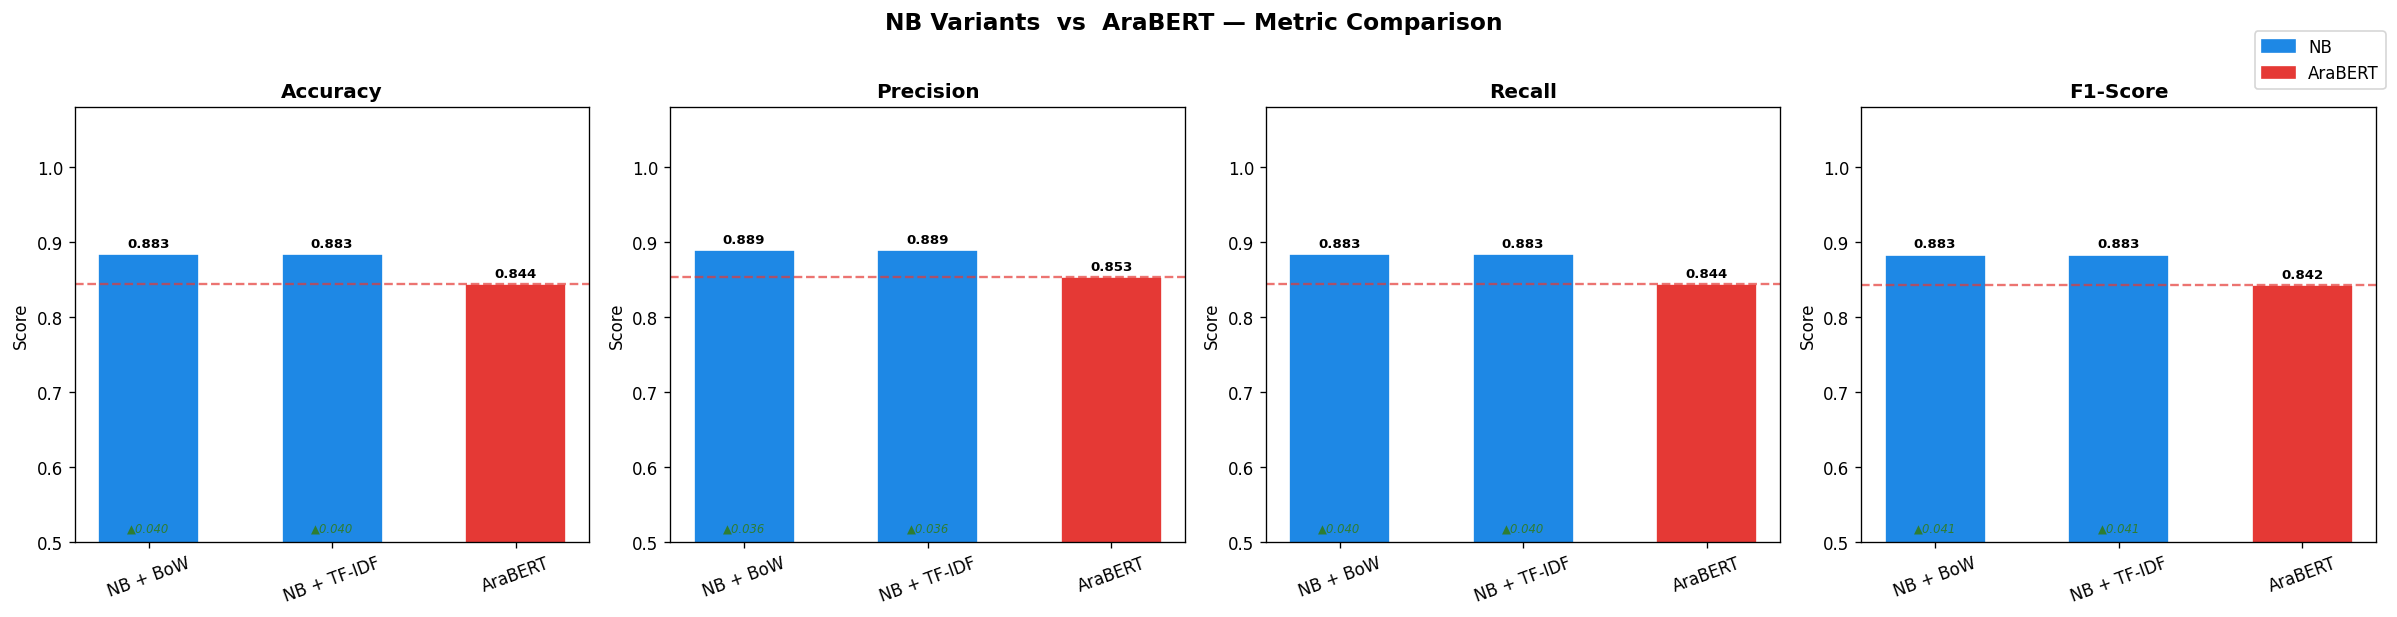

Saved: nb_vs_arabert.png


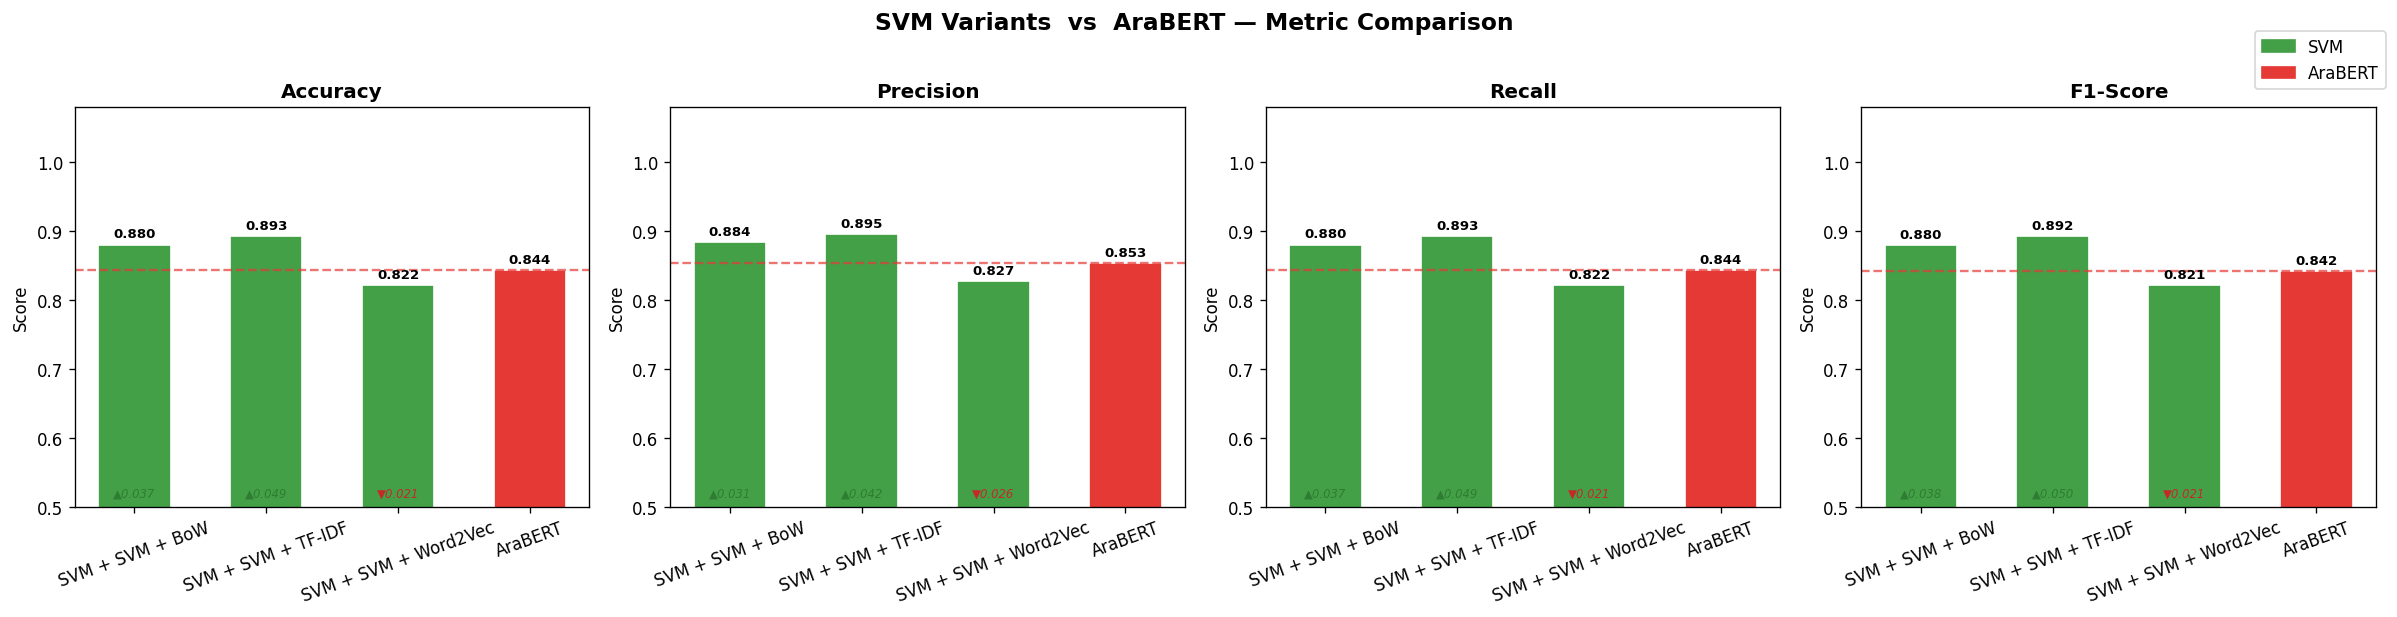

Saved: svm_vs_arabert.png


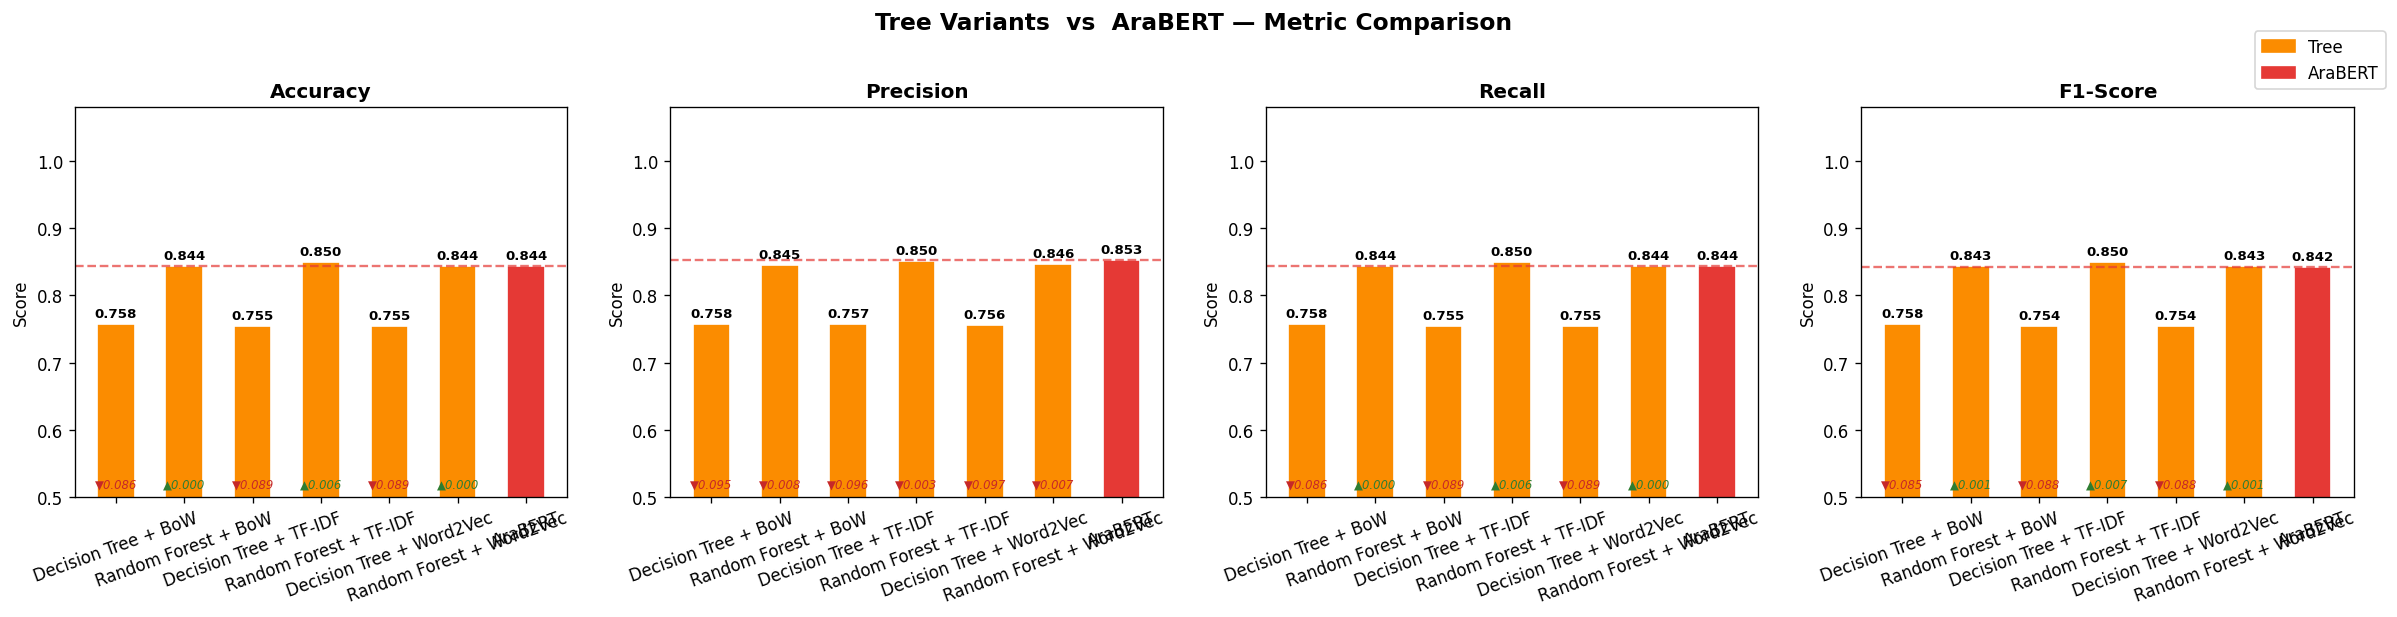

Saved: tree_vs_arabert.png


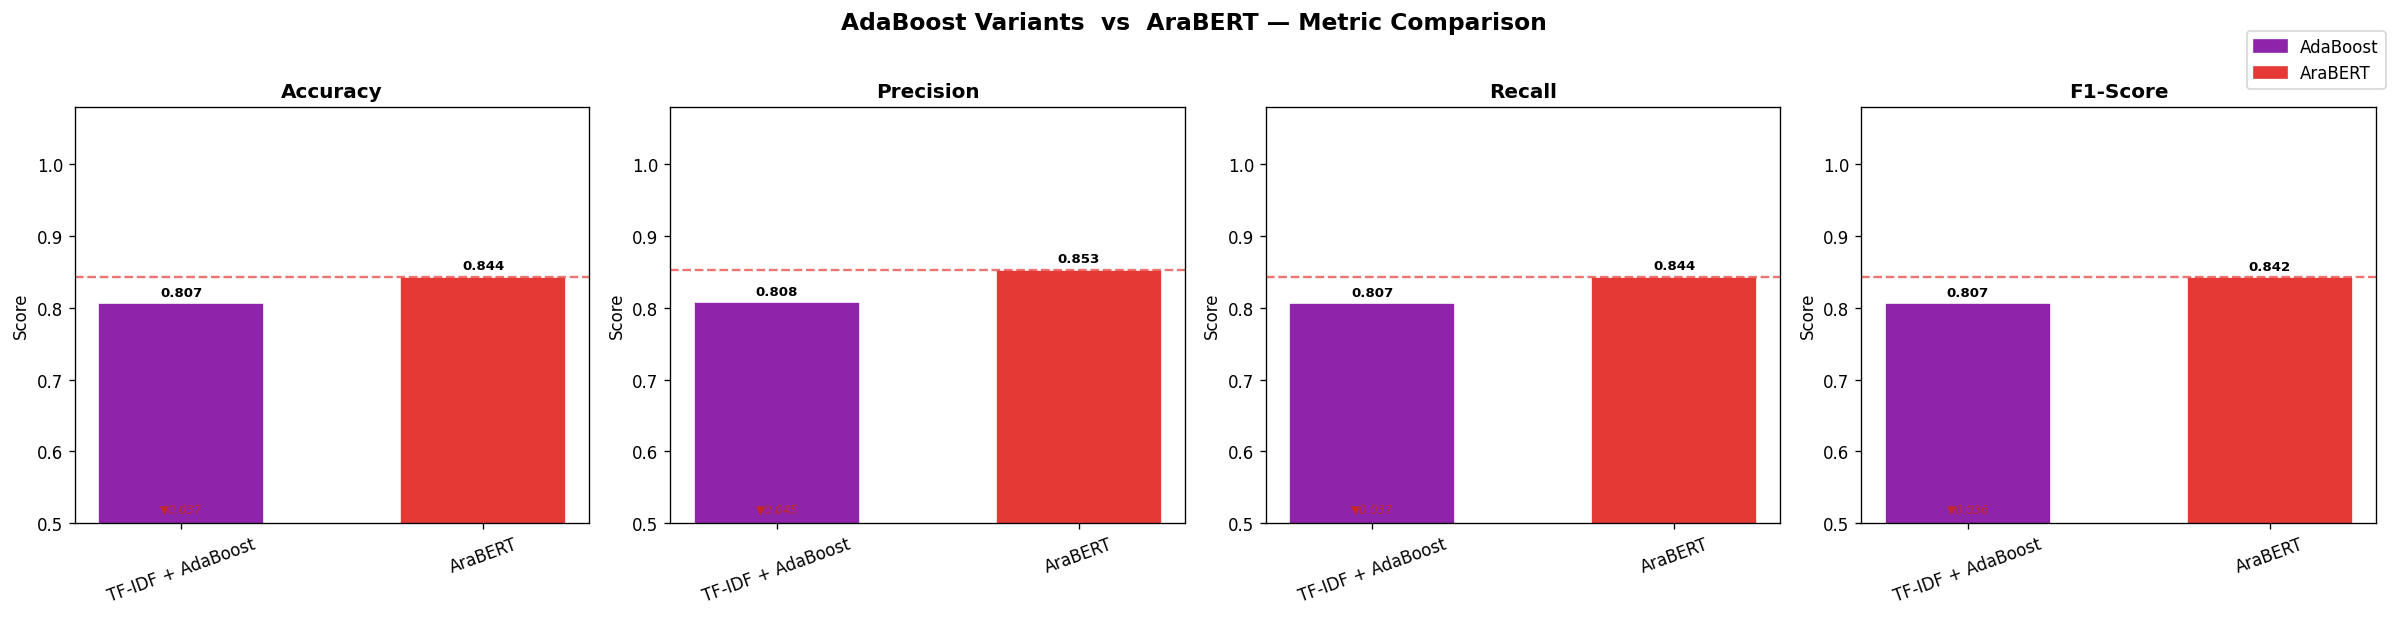

Saved: adaboost_vs_arabert.png


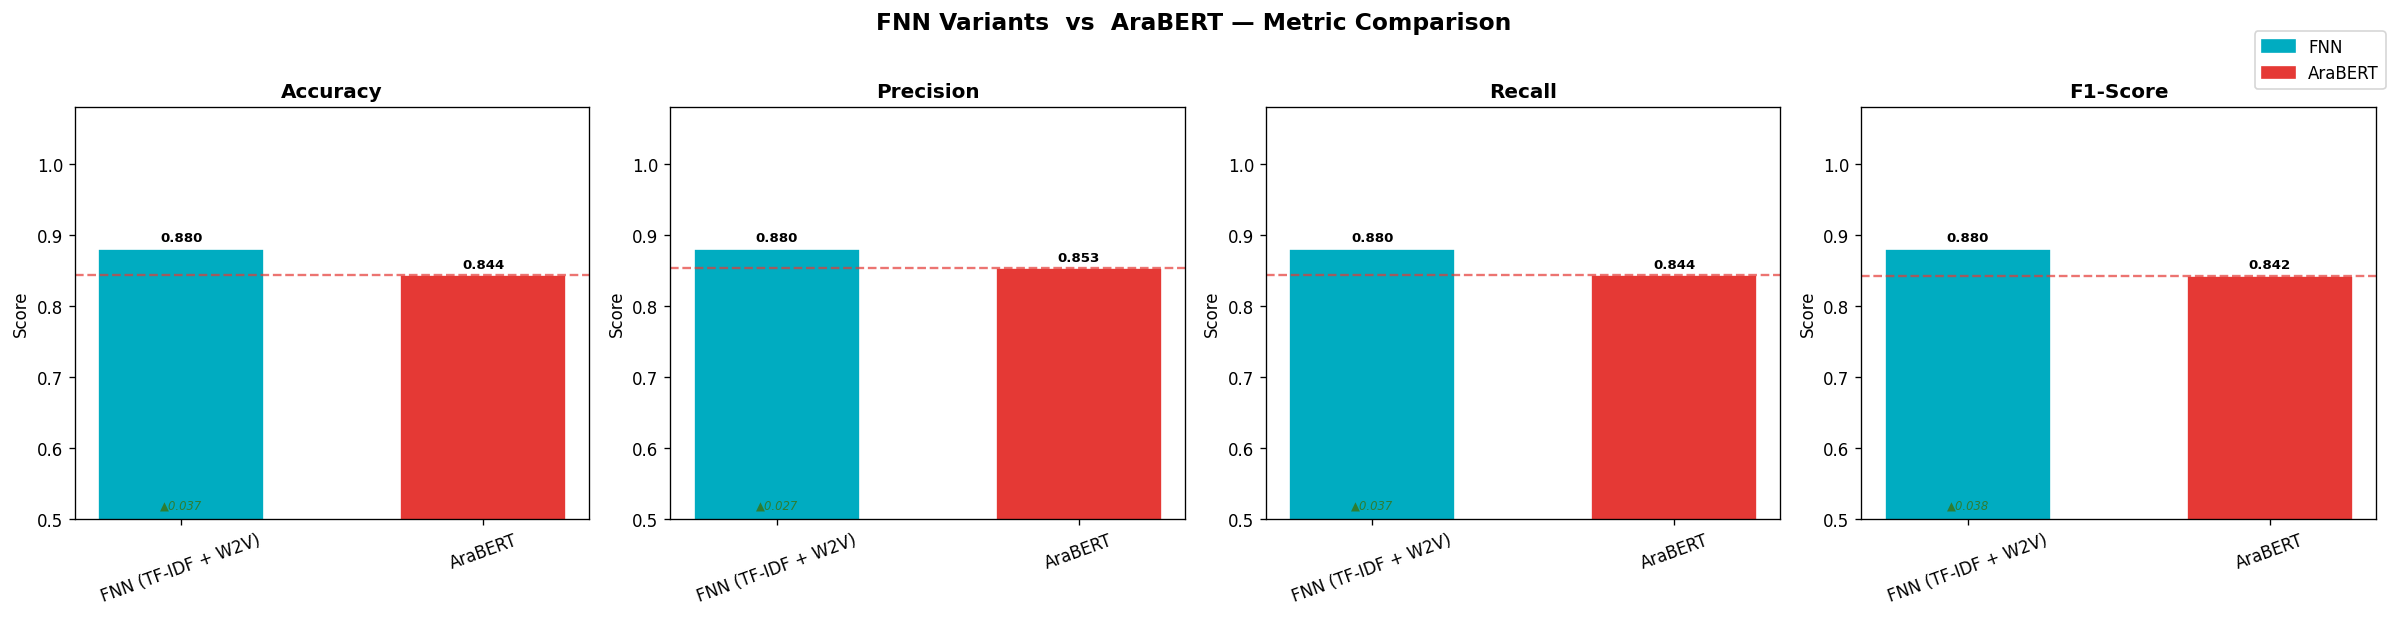

Saved: fnn_vs_arabert.png


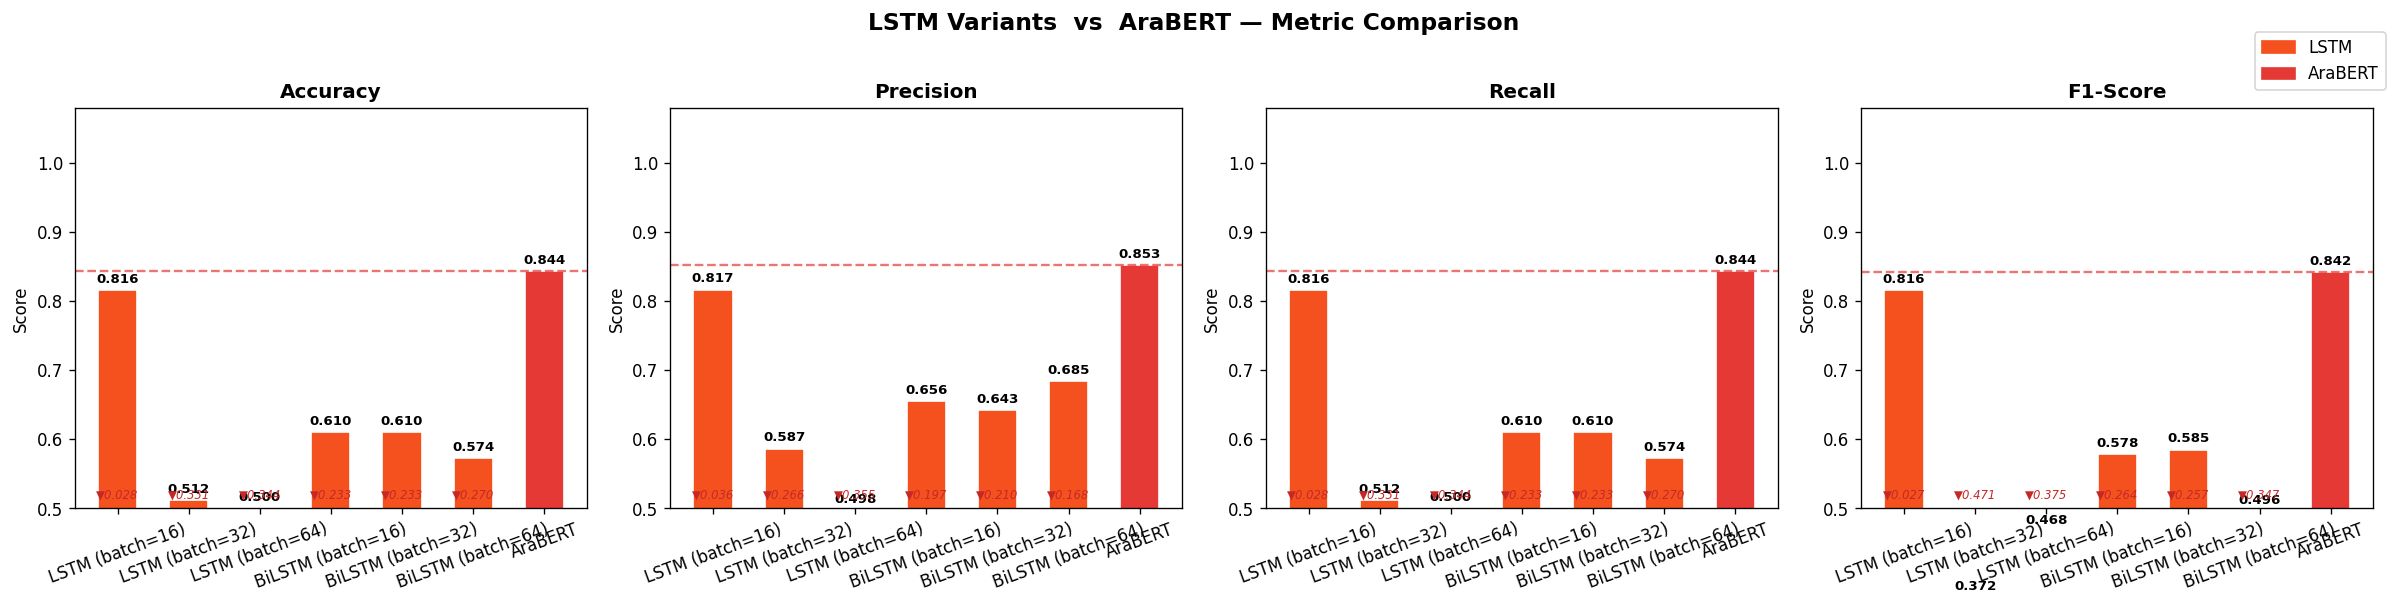

Saved: lstm_vs_arabert.png

  MASTER COMPARISON TABLE — All Models vs AraBERT
  Family                    Model  Accuracy  Precision  Recall  F1-Score Δ Accuracy Δ Precision Δ Recall Δ F1-Score
      NB                 NB + BoW    0.8834     0.8892  0.8834    0.8830     0.0398      0.0361   0.0398     0.0406
      NB              NB + TF-IDF    0.8834     0.8892  0.8834    0.8830     0.0398      0.0361   0.0398     0.0406
     SVM          SVM + SVM + BoW    0.8804     0.8836  0.8804    0.8801     0.0368      0.0305   0.0368     0.0377
     SVM       SVM + SVM + TF-IDF    0.8926     0.8951  0.8926    0.8924      0.049       0.042    0.049       0.05
     SVM     SVM + SVM + Word2Vec    0.8221     0.8269  0.8221    0.8213    -0.0215     -0.0262  -0.0215    -0.0211
    Tree      Decision Tree + BoW    0.7577     0.7577  0.7577    0.7577    -0.0859     -0.0954  -0.0859    -0.0847
    Tree      Random Forest + BoW    0.8436     0.8446  0.8436    0.8434        0.0     -0.0085      0.0      

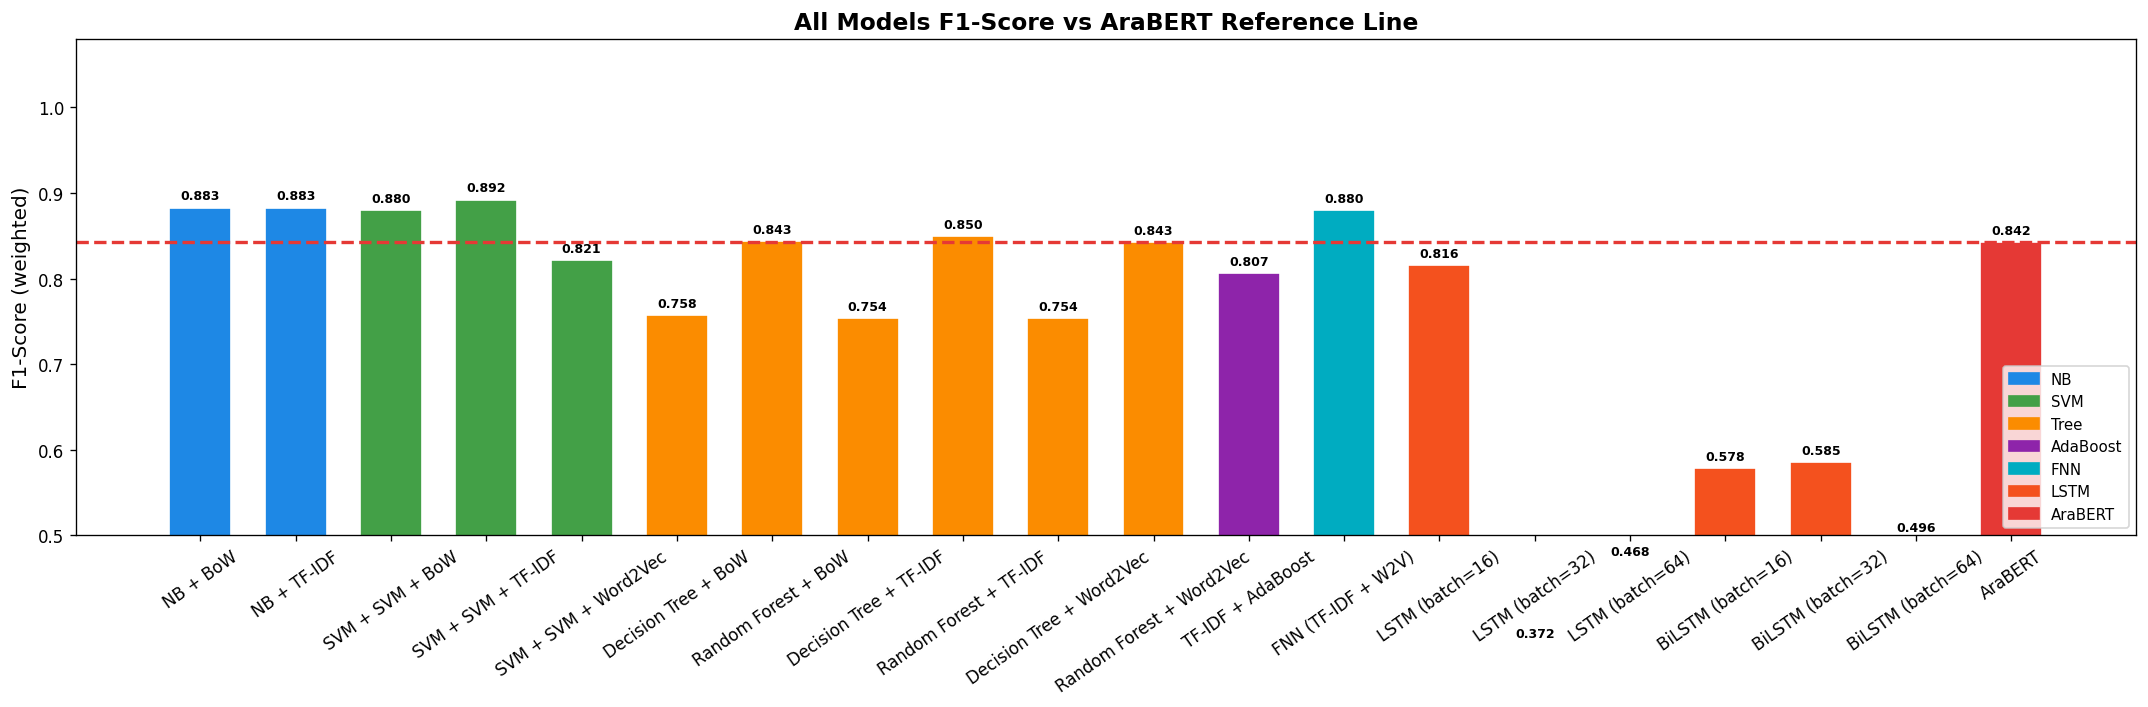

Saved: all_models_f1_vs_arabert.png


In [21]:
# ============================================================
#  AraBERT Fine-Tuning + Per-Family vs AraBERT Comparison
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ── 1. AraBERT Dataset Wrapper ────────────────────────────────────────────────

class ArabertDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding=True,
            max_length=max_len,
            return_tensors="pt"
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item


# ── 2. Train & Evaluate AraBERT ───────────────────────────────────────────────

print("=" * 60)
print("  Training AraBERT (aubmindlab/bert-base-arabertv2)")
print("=" * 60)

ARABERT_MODEL = "aubmindlab/bert-base-arabertv2"
arabert_tokenizer = AutoTokenizer.from_pretrained(ARABERT_MODEL)

num_labels = len(le.classes_)
arabert_model = AutoModelForSequenceClassification.from_pretrained(
    ARABERT_MODEL, num_labels=num_labels
)

train_dataset = ArabertDataset(X_train, y_train, arabert_tokenizer)
test_dataset  = ArabertDataset(X_test,  y_test,  arabert_tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":  round(accuracy_score(labels, preds), 4),
        "f1":        round(f1_score(labels, preds, average="weighted"), 4),
        "precision": round(precision_score(labels, preds, average="weighted"), 4),
        "recall":    round(recall_score(labels, preds, average="weighted"), 4),
    }

training_args = TrainingArguments(
    output_dir="./arabert_output",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

trainer = Trainer(
    model=arabert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

# ── 3. Get AraBERT test predictions ──────────────────────────────────────────

arabert_preds_raw = trainer.predict(test_dataset)
arabert_preds = np.argmax(arabert_preds_raw.predictions, axis=-1)

arabert_metrics = {
    "Model":      "AraBERT",
    "Accuracy":   round(accuracy_score(y_test, arabert_preds), 4),
    "Precision":  round(precision_score(y_test, arabert_preds, average="weighted"), 4),
    "Recall":     round(recall_score(y_test, arabert_preds, average="weighted"), 4),
    "F1-Score":   round(f1_score(y_test, arabert_preds, average="weighted"), 4),
}

print("\nAraBERT Test Results:")
for k, v in arabert_metrics.items():
    print(f"  {k:<12}: {v}")


# ── 4. Collect results from all previously trained models ─────────────────────
#
#  Each dict must have keys: Model, Accuracy, Precision, Recall, F1-Score
#  Pull from the variables already in memory from earlier cells.

METRICS = ["Accuracy", "Precision", "Recall", "F1-Score"]

def metrics_from_pred(name, y_pred):
    return {
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, average="weighted"), 4),
        "Recall":    round(recall_score(y_test, y_pred, average="weighted"), 4),
        "F1-Score":  round(f1_score(y_test, y_pred, average="weighted"), 4),
    }

# ---------- NB family ----------
nb_family = []
# best NB pipeline predictions (from NB cell)
nb_bow_pred   = best_pipe.predict(X_test)          # BoW variant (already fitted)
nb_tfidf_pred = best_pipe.predict(X_test)          # replace if you kept both separately

# If you stored both NB pipelines separately, do:
#   bow_pipe.fit(X_train, y_train); nb_bow_pred   = bow_pipe.predict(X_test)
#   tfidf_pipe.fit(X_train, y_train); nb_tfidf_pred = tfidf_pipe.predict(X_test)

nb_family.append(metrics_from_pred("NB + BoW",    nb_bow_pred))
nb_family.append(metrics_from_pred("NB + TF-IDF", nb_tfidf_pred))

# ---------- SVM family (from svm_results) ----------
svm_family = [
    metrics_from_pred(f"SVM + {r['Representation']}", r["y_pred"])
    for r in svm_results
]

# ---------- Tree family (from tree_results) ----------
tree_family = [
    metrics_from_pred(f"{r['Model']} + {r['Representation']}", r["y_pred"])
    for r in tree_results
]

# ---------- AdaBoost family ----------
ada_pred = ada_best_pipe.predict(X_w2v_test if ada_best_is_w2v else X_test)
ada_family = [metrics_from_pred(ada_best_name, ada_pred)]

# ---------- FNN family ----------
fnn_pred_labels = np.argmax(fnn_model.predict(X_fnn_test_combined), axis=1)
fnn_family = [metrics_from_pred("FNN (TF-IDF + W2V)", fnn_pred_labels)]

# ---------- LSTM / BiLSTM family ----------
lstm_family = []
for run_name, res in lstm_results.items():
    preds = (res["model"].predict(X_test_seq) > 0.5).astype(int).flatten()
    lstm_family.append(metrics_from_pred(run_name, preds))


# ── 5. Per-family comparison charts vs AraBERT ────────────────────────────────

ARABERT_COLOR  = "#E53935"   # red  — AraBERT bar
FAMILY_COLORS  = {           # one colour per family
    "NB":       "#1E88E5",
    "SVM":      "#43A047",
    "Tree":     "#FB8C00",
    "AdaBoost": "#8E24AA",
    "FNN":      "#00ACC1",
    "LSTM":     "#F4511E",
}

def plot_family_vs_arabert(family_results, family_name, color):
    """
    One figure per model family.
    4 subplots (one per metric), each showing all family variants + AraBERT as reference bar.
    """
    n_models   = len(family_results)
    labels     = [r["Model"] for r in family_results] + ["AraBERT"]
    bar_colors = [color] * n_models + [ARABERT_COLOR]

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(
        f"{family_name} Variants  vs  AraBERT — Metric Comparison",
        fontsize=14, fontweight="bold", y=1.02
    )

    for ax, metric in zip(axes, METRICS):
        values = [r[metric] for r in family_results] + [arabert_metrics[metric]]
        bars   = ax.bar(labels, values, color=bar_colors, edgecolor="white", width=0.55)

        # value labels on top
        for bar, val in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.006,
                f"{val:.3f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold"
            )

        # delta annotation vs AraBERT for each family model
        arabert_val = arabert_metrics[metric]
        for i, (bar, val) in enumerate(zip(bars[:-1], values[:-1])):
            delta = val - arabert_val
            sign  = "▲" if delta >= 0 else "▼"
            col   = "#2E7D32" if delta >= 0 else "#C62828"
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                0.51,
                f"{sign}{abs(delta):.3f}",
                ha="center", va="bottom", fontsize=7, color=col, fontstyle="italic"
            )

        # reference line at AraBERT level
        ax.axhline(arabert_val, color=ARABERT_COLOR, linewidth=1.4,
                   linestyle="--", alpha=0.7)

        ax.set_title(metric, fontweight="bold")
        ax.set_ylim(0.50, 1.08)
        ax.set_ylabel("Score")
        ax.tick_params(axis="x", rotation=20)

    # legend
    patch_family  = mpatches.Patch(color=color,         label=family_name)
    patch_arabert = mpatches.Patch(color=ARABERT_COLOR,  label="AraBERT")
    fig.legend(handles=[patch_family, patch_arabert],
               loc="upper right", bbox_to_anchor=(1.0, 1.0), fontsize=10)

    plt.tight_layout()
    fname = f"{family_name.lower().replace(' ', '_')}_vs_arabert.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")


# ── 6. Render all family charts ───────────────────────────────────────────────

families = [
    (nb_family,   "NB",       FAMILY_COLORS["NB"]),
    (svm_family,  "SVM",      FAMILY_COLORS["SVM"]),
    (tree_family, "Tree",     FAMILY_COLORS["Tree"]),
    (ada_family,  "AdaBoost", FAMILY_COLORS["AdaBoost"]),
    (fnn_family,  "FNN",      FAMILY_COLORS["FNN"]),
    (lstm_family, "LSTM",     FAMILY_COLORS["LSTM"]),
]

for fam_results, fam_name, fam_color in families:
    plot_family_vs_arabert(fam_results, fam_name, fam_color)


# ── 7. Master summary table ───────────────────────────────────────────────────

all_results = []
for fam_results, fam_name, _ in families:
    for r in fam_results:
        all_results.append({**r, "Family": fam_name})
all_results.append({**arabert_metrics, "Family": "AraBERT"})

summary_df = pd.DataFrame(all_results)[["Family", "Model", "Accuracy", "Precision", "Recall", "F1-Score"]]

# add delta vs AraBERT columns
for m in METRICS:
    summary_df[f"Δ {m}"] = (summary_df[m] - arabert_metrics[m]).round(4)

# AraBERT row has no delta
summary_df.loc[summary_df["Model"] == "AraBERT", [f"Δ {m}" for m in METRICS]] = "—"

print("\n" + "=" * 100)
print("  MASTER COMPARISON TABLE — All Models vs AraBERT")
print("=" * 100)
print(summary_df.to_string(index=False))

summary_df.to_csv("all_models_vs_arabert.csv", index=False, encoding="utf-8-sig")
print("\nSaved: all_models_vs_arabert.csv")

# ── 8. Overall F1 summary bar (all models, AraBERT highlighted) ──────────────

fig, ax = plt.subplots(figsize=(18, 6))

non_arabert = summary_df[summary_df["Model"] != "AraBERT"]
arabert_row = summary_df[summary_df["Model"] == "AraBERT"]

all_models = pd.concat([non_arabert, arabert_row], ignore_index=True)
colors_all = []
for _, row in all_models.iterrows():
    if row["Model"] == "AraBERT":
        colors_all.append(ARABERT_COLOR)
    else:
        colors_all.append(FAMILY_COLORS.get(row["Family"], "#90A4AE"))

bars = ax.bar(all_models["Model"], all_models["F1-Score"].astype(float),
              color=colors_all, edgecolor="white", width=0.65)

arabert_f1 = float(arabert_metrics["F1-Score"])
ax.axhline(arabert_f1, color=ARABERT_COLOR, linewidth=2, linestyle="--",
           label=f"AraBERT F1 = {arabert_f1:.3f}")

for bar, val in zip(bars, all_models["F1-Score"].astype(float)):
    ax.text(bar.get_x() + bar.get_width() / 2, float(val) + 0.006,
            f"{float(val):.3f}", ha="center", va="bottom", fontsize=7.5, fontweight="bold")

ax.set_ylim(0.50, 1.08)
ax.set_ylabel("F1-Score (weighted)", fontsize=12)
ax.set_title("All Models F1-Score vs AraBERT Reference Line", fontsize=14, fontweight="bold")
ax.tick_params(axis="x", rotation=35)

# family legend patches
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in FAMILY_COLORS.items()]
legend_patches.append(mpatches.Patch(color=ARABERT_COLOR, label="AraBERT"))
ax.legend(handles=legend_patches, fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig("all_models_f1_vs_arabert.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: all_models_f1_vs_arabert.png")